# Presentation deck

**Run from repository root** (directory containing `utils/`). **Environment:** `matplotlib`, `seaborn`, `pandas`, `scikit-learn`, `IPython`.

**Notes convention:** short titles in markdown; longer speaker copy in **Speaker script** sections or collapsed **Glossary**. **Deck exports** under `figures/presentation/`: **`save_deck_png_svg`** (PNG 300 dpi + SVG). Legacy **`save_display`** remains only where a PDF sidecar is still intentional.

## Outline — Acts I–IV

- **Act I** — Motivation + Liberman **Group×frequency** ceiling (not ABR); per-group RMSE + stratum means (small horizontal offset between noise strata when needed) / median spread.
- **Act Ib** — Liberman **`C`**: OLS **O1→O2→O3** (parquet marks) + Stage 1 **ROC / calibration** (wide LR+RF).
- **Act II** — Classical RMSE strips (after the linear ladder): **IIb** Liberman **`C`**, optional **IIa**/**IIc**, recap.
- **Act III** — Two panels per cohort (**NN-only**, then **best linear / tree / neural**): Liberman main spine, Brad epilogue; **PNG+SVG** (no PDF on deck exports).
- **Act IV** — RMSE synthesis vs ceilings (Liberman then Brad); closing themes.

## Act I — Motivation and ceiling

**Three questions (say early):**
1. **Simple group-and-frequency rule:** How well can we guess synapses knowing only **which noise exposure stratum (`noise_cat` / `Group`)** and **which test frequency** (no ABR)? That is the **noise_cat×frequency ceiling (Liberman) / Group×frequency (Liberman legacy label)**.
2. **ABR-only:** How close can models get using **only** ABR-derived inputs? We **do not** expect them to match the ceiling — it uses experimental metadata ABR never sees.
3. **Individual prediction:** Target grain is **`animal_id`×`frequency`**; high scores vs the ceiling do **not** prove **within-stratum** personalization vs the stratum mean.

**Notes:** ceiling is a **reference**, not a fair horse race against ABR.

### Setup + cache load

In [1]:
%matplotlib inline
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from utils.benchmark_metrics import (
    BENCHMARK_DISPLAY_ORDER,
    CACHE_DIR,
    CLASSICAL_BENCHMARK_PARQUET,
    LIBERMAN_GROUP_BASELINE_TEST_BY_GROUP_PARQUET,
    LIBERMAN_GROUP_MEAN_BASELINE_PARQUET,
    LIBERMAN_SYNAPSE_MEAN_STD_BY_GROUP_FREQ_PARQUET,
    NN_ALL_LONG_FACE,
    NN_METRICS_PARQUET,
    STAGE1_WIDE_RF_METRICS_JSON,
    VARIANT_PALETTE,
    RMSE_Y_AXIS_MARGIN_HINT,
    apply_benchmark_grid,
    apply_slide_rcparams,
    load_benchmark_from_cache,
    repo_root,
)
from utils.nn_stage2_data import load_nn_stage2_data, splits_for_long_stage2

OUT_DIR = repo_root() / "figures" / "presentation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

apply_slide_rcparams()

FIG_BOTTOM_FOOTER = 0.22  # legacy constant; RMSE-strip exports no longer use bottom fig.text footers


def set_rmse_y_margin_label(ax, *, label_x: float = -0.16) -> None:
    """Rotated RMSE label + same worse/better hint as ``plot_unified_benchmark`` (RMSE).

    ``label_x`` is in axes coordinates (negative = left of the y-axis); more negative
    moves the block away from the axis (use for Act III / IIc when subplots ``left`` is larger).
    """
    ax.set_ylabel("")
    margin_lbl = "RMSE\n" + RMSE_Y_AXIS_MARGIN_HINT
    ax.text(
        label_x,
        0.5,
        margin_lbl,
        transform=ax.transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=15,
        linespacing=1.85,
        clip_on=False,
    )


def noise_group_legend_label(g) -> str:
    """Legend text for Liberman noise exposure (parquet ``Group`` / ``noise_cat``)."""
    gs = str(g).strip()
    if gs in ("0", "0.0"):
        return "Lower noise (<91 dB SPL)"
    if gs in ("1", "1.0"):
        return "Higher noise (≥91 dB SPL)"
    return gs


def add_long_wide_variant_legend(
    fig, *, loc: str = "lower center", bbox_to_anchor: tuple[float, float] = (0.5, 0.02)
) -> None:
    """Legend for classical strips: dot color = long vs wide (matches benchmark palette)."""
    handles = [
        mlines.Line2D(
            [],
            [],
            color=VARIANT_PALETTE["all-long"],
            marker="o",
            linestyle="None",
            markersize=9,
            label="Long-format feature table",
        ),
        mlines.Line2D(
            [],
            [],
            color=VARIANT_PALETTE["all-wide"],
            marker="o",
            linestyle="None",
            markersize=9,
            label="Wide-format feature table",
        ),
    ]
    fig.legend(
        handles=handles,
        loc=loc,
        bbox_to_anchor=bbox_to_anchor,
        ncol=2,
        fontsize=12,
        frameon=True,
    )


# Full footer checklist (use footer_text(...) per figure with relevant kwargs):
# Test · Train scenario · Variants · Target grain · Ceiling (Group×freq = no ABR) · Models
FOOTER_TEMPLATE_DOC = (
    "Test · Train scenario · Variants · Target grain · "
    "Ceiling (Group×freq = no ABR) · Models"
)


def save_display(fig, name: str) -> None:
    p = OUT_DIR / name
    fig.savefig(p, dpi=300, bbox_inches="tight", pad_inches=0.12)
    display(fig)
    plt.close(fig)
    print("Saved", p.resolve())


def save_deck_png_svg(fig, name: str) -> None:
    """Deck workbook policy: PNG (300 dpi) + SVG only — no PDF."""
    p = OUT_DIR / (name if name.endswith(".png") else f"{name}.png")
    fig.savefig(p, dpi=300, bbox_inches="tight", pad_inches=0.12)
    fig.savefig(p.with_suffix(".svg"), bbox_inches="tight", pad_inches=0.12)
    display(fig)
    plt.close(fig)
    print("Saved", p.resolve(), "+", p.with_suffix(".svg").resolve())


def footer_text(**parts) -> str:
    return " · ".join(f"{k}={v}" for k, v in parts.items() if v is not None)


def filter_classical(df: pd.DataFrame) -> pd.DataFrame:
    m = df["source"].eq("classical") & df["variant"].isin(("all-long", "all-wide"))
    return df.loc[m].copy()


def filter_merged_nn_safe(df: pd.DataFrame) -> pd.DataFrame:
    m = df["source"].eq("nn") | (
        df["source"].eq("classical") & df["variant"].isin(("all-long", "all-wide"))
    )
    return df.loc[m].copy()


def pick_best_long_wide_classical(sub: pd.DataFrame) -> pd.DataFrame:
    """Keep lower-RMSE variant per (test_set, scenario, model) for classical long vs wide."""
    nn = sub.loc[sub["source"].eq("nn")]
    cl = sub.loc[sub["source"].eq("classical")]
    if cl.empty:
        return sub
    rows: list[pd.DataFrame] = []
    for (_, _, _), grp in cl.groupby(["test_set", "scenario", "model"], dropna=False):
        g2 = grp.loc[grp["variant"].astype(str).isin(("all-long", "all-wide"))]
        if g2.empty:
            rows.append(grp)
        else:
            idx = g2["RMSE"].astype(float).idxmin()
            rows.append(g2.loc[[idx]])
    cl_out = pd.concat(rows, ignore_index=True) if rows else cl.iloc[0:0]
    return pd.concat([cl_out, nn], ignore_index=True)


def dodge_offsets(variants_present: list[str]) -> dict[str, float]:
    n = len(variants_present)
    if n <= 0:
        return {}
    if n == 1:
        return {variants_present[0]: 0.0}
    span = 0.22
    offs = list(np.linspace(-span / 2, span / 2, n))
    return {v: offs[i] for i, v in enumerate(variants_present)}


def _vlines(ax, n: int) -> None:
    for xv in range(n):
        ax.axvline(xv, color="0.70", linewidth=0.9, linestyle=(0, (1, 2)), alpha=0.88, zorder=0)


def scatter_classical_rmse(
    ax,
    sub: pd.DataFrame,
    *,
    x_slots: int = 4,
    rmse_label_x: float = -0.16,
) -> None:
    # Scatter RMSE for classical rows; x positions 0 .. x_slots-1 (default first four models).
    order = list(BENCHMARK_DISPLAY_ORDER[:x_slots])
    cls = sub[sub["model"].isin(order)].copy()
    if cls.empty:
        ax.text(0.5, 0.5, "No classical rows", ha="center", va="center", transform=ax.transAxes)
        return
    present = [
        v
        for v in ("all-long", "all-wide")
        if v in set(cls["variant"].dropna().astype(str).unique())
    ]
    dxmap = dodge_offsets(present)
    for _, row in cls.iterrows():
        m = row["model"]
        if m not in order:
            continue
        mi = order.index(m)
        v = str(row["variant"])
        if v not in dxmap:
            continue
        dx = dxmap[v]
        c = VARIANT_PALETTE.get(v, "0.45")
        ax.scatter(mi + dx, float(row["RMSE"]), s=105, c=c, edgecolors="0.25", linewidths=0.75, zorder=5)
    ax.set_axisbelow(True)
    apply_benchmark_grid(ax, n_models=x_slots)
    ax.set_xticks(range(x_slots))
    ax.set_xticklabels(
        ["LR base", "LR full", "RF", "XGB"][:x_slots], rotation=26, ha="right"
    )
    sns.despine(ax=ax)
    set_rmse_y_margin_label(ax, label_x=rmse_label_x)


def scatter_classical_rmse_on_full_axis(ax, sub: pd.DataFrame, *, n_models: int = 7) -> None:
    # Classical only for first four model indices on an axis prepared for n_models (0..6).
    order4 = list(BENCHMARK_DISPLAY_ORDER[:4])
    cls = sub[sub["model"].isin(order4)].copy()
    present = [
        v
        for v in ("all-long", "all-wide")
        if not cls.empty and v in set(cls["variant"].dropna().astype(str).unique())
    ]
    dxmap = dodge_offsets(present)
    for _, row in cls.iterrows():
        m = row["model"]
        if m not in order4:
            continue
        mi = order4.index(m)
        v = str(row["variant"])
        if v not in dxmap:
            continue
        dx = dxmap[v]
        c = VARIANT_PALETTE.get(v, "0.45")
        ax.scatter(mi + dx, float(row["RMSE"]), s=105, c=c, edgecolors="0.25", linewidths=0.75, zorder=5)
    ax.set_axisbelow(True)
    apply_benchmark_grid(ax, n_models=n_models)


def scatter_nn_rmse(ax, sub: pd.DataFrame, *, x0: int = 4) -> None:
    nn = sub[sub["source"].eq("nn")].copy()
    for _, row in nn.iterrows():
        m = row["model"]
        if m not in BENCHMARK_DISPLAY_ORDER:
            continue
        mi = BENCHMARK_DISPLAY_ORDER.index(m)
        if mi < x0:
            continue
        ax.scatter(
            mi,
            float(row["RMSE"]),
            s=105,
            c=NN_ALL_LONG_FACE,
            edgecolors="0.25",
            linewidths=0.75,
            zorder=8,
        )


# --- Cache paths & guards (same cell as setup so imports always run first) ---
# Paths resolve via utils.benchmark_metrics (repo root + optional ABR2synapse/figures/cache).
LIB = LIBERMAN_GROUP_MEAN_BASELINE_PARQUET
LIB_GF = LIBERMAN_SYNAPSE_MEAN_STD_BY_GROUP_FREQ_PARQUET
LIB_PG = LIBERMAN_GROUP_BASELINE_TEST_BY_GROUP_PARQUET
CL = CLASSICAL_BENCHMARK_PARQUET
NNP = NN_METRICS_PARQUET
S1 = STAGE1_WIDE_RF_METRICS_JSON

missing = [p for p in (LIB, LIB_GF, LIB_PG) if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing Liberman baseline exports: "
        + ", ".join(str(p) for p in missing)
        + "\nRun liberman_synapses_group_baseline.ipynb export cells "
        "(writes under figures/cache at repo root or under ABR2synapse/figures/cache)."
    )
if not CL.exists():
    raise FileNotFoundError(
        f"Missing {CL} — run abr_wide_long_comparison.ipynb export of classical_benchmark_long.parquet "
        "(searched repo figures/cache and ABR2synapse/figures/cache)."
    )
if not NNP.exists():
    warnings.warn(
        f"Missing {NNP}: Act III/IV NN points unavailable. Run abr_nn_stage2 export.",
        stacklevel=1,
    )
benchmark_df = None
if NNP.exists():
    benchmark_df = load_benchmark_from_cache(save_merged=CACHE_DIR / "benchmark_metrics.parquet")
else:
    benchmark_df = pd.read_parquet(CL)
    benchmark_df["source"] = "classical"
assert benchmark_df is not None and len(benchmark_df) > 0, "benchmark_df is empty after cache load"
_req = {"RMSE", "test_set", "scenario", "model", "source"}
_missing_cols = sorted(_req - set(benchmark_df.columns))
assert not _missing_cols, f"benchmark_df missing columns: {_missing_cols}"
print("Cache OK; benchmark_df rows:", len(benchmark_df))
print("FOOTER_TEMPLATE_DOC:", FOOTER_TEMPLATE_DOC)


Cache OK; benchmark_df rows: 90
FOOTER_TEMPLATE_DOC: Test · Train scenario · Variants · Target grain · Ceiling (Group×freq = no ABR) · Models


<details><summary><strong>Glossary — overloaded “baseline”</strong> (click to expand)</summary>

| Label | Meaning |
|--------|--------|
| **noise_cat×frequency ceiling (Liberman) / Group×frequency (Liberman legacy label)** | Train mean synapses per `(Group, frequency)`; **no ABR**; constant prediction within each stratum. |
| **OLS / LR baseline (Brad)** | Sparse amplitude @ 80 dB-style **minimal** linear ABR model — **not** the ceiling. |
| **OLS / LR full** | Richer tabular ABR features ± Stage 1 noise column (per wide/long notebook). |
| **Stage 1** | Noise classifier from ABR wide features; **not** a synapse “baseline.” |

</details>

### Act I figures

Ceiling headline — parquet: /Users/nowaki027/MSDS/Practicum/figures/cache/liberman_group_mean_baseline_metrics.parquet
  R²=0.424066±0.0619458  RMSE=2.341969±0.0987528  (10-fold CV, Liberman wide; SEM across folds)


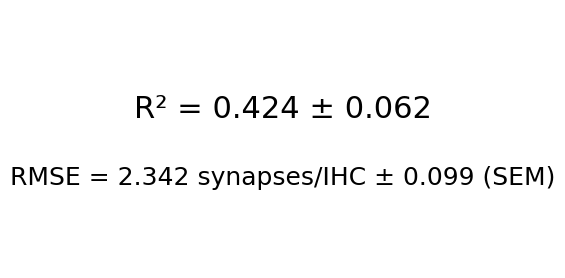

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_ceiling_headline.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_ceiling_headline.svg


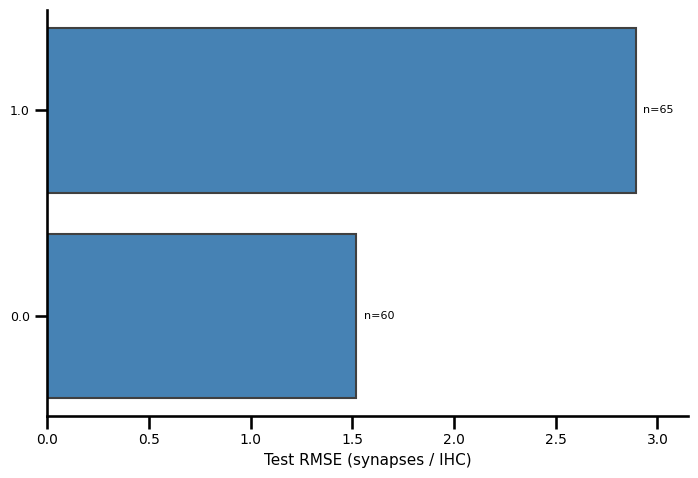

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_per_group_rmse_bars.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_per_group_rmse_bars.svg


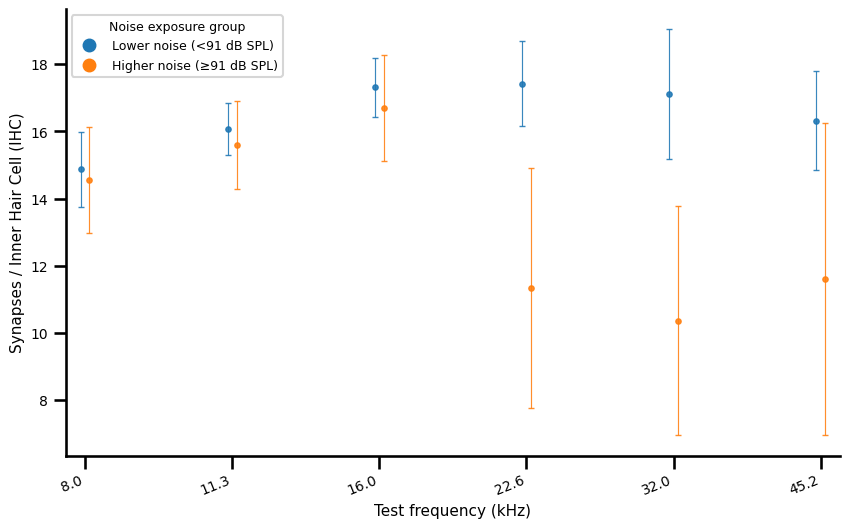

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons_by_group.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons_by_group.svg


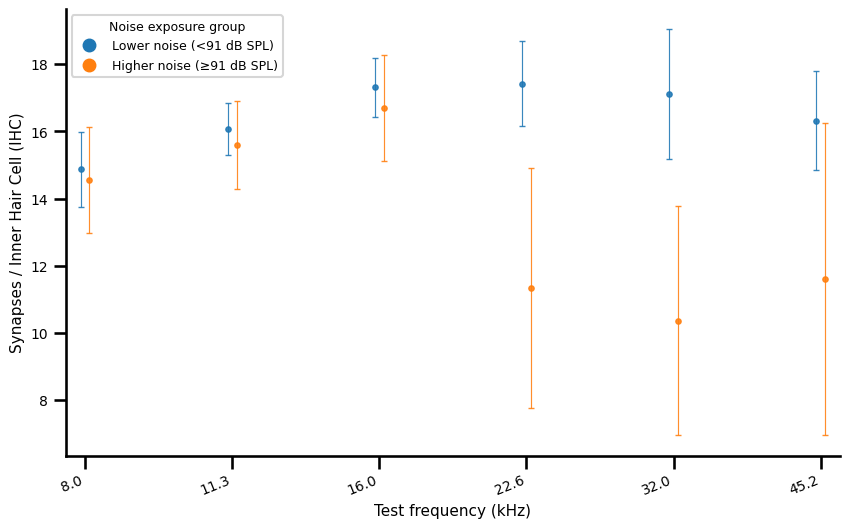

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons.svg


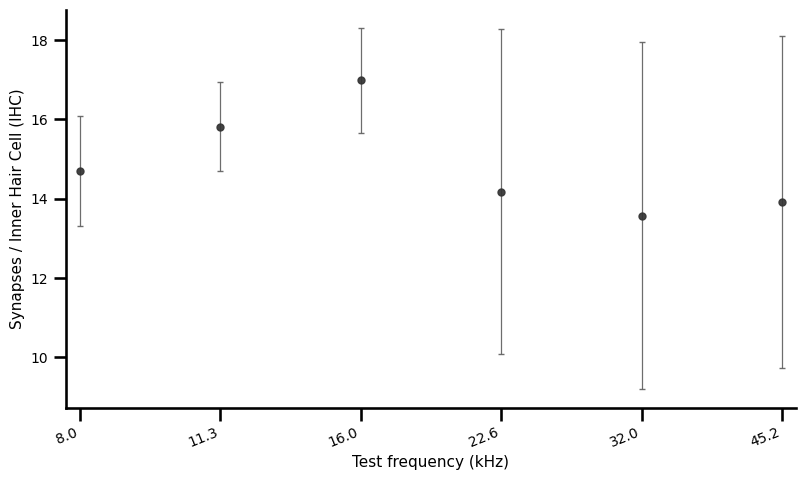

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons_global.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons_global.svg


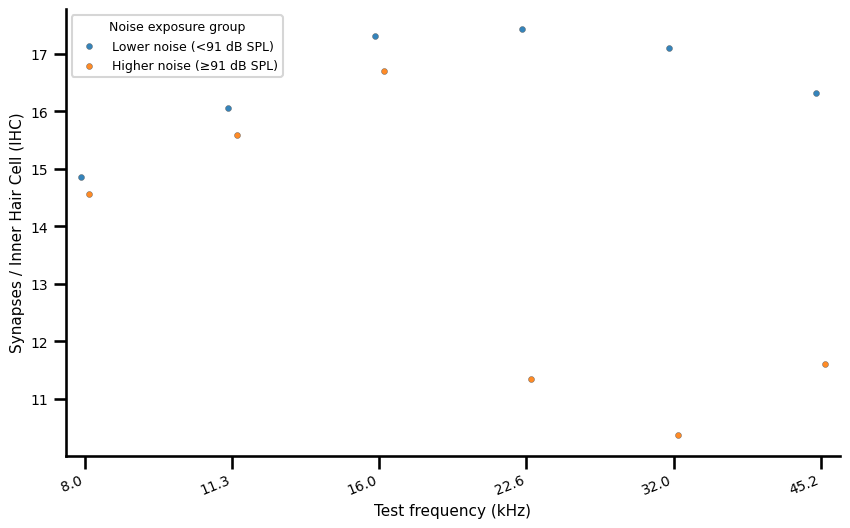

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons_scatter.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons_scatter.svg


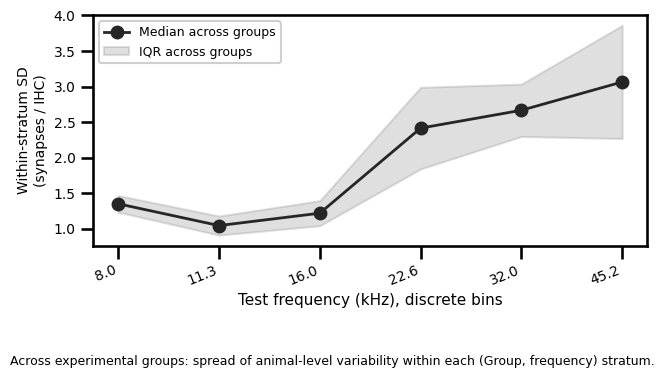

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_std_median_by_frequency.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_std_median_by_frequency.svg
std_synapses quantiles:
 0.25    1.231084
0.50    1.522600
0.75    2.298704
Name: std_synapses, dtype: float64
max mean_synapses: 17.42291069959602 Group 0.0 freq 22.6
min mean_synapses: 10.364271501586712 Group 1.0 freq 32.0


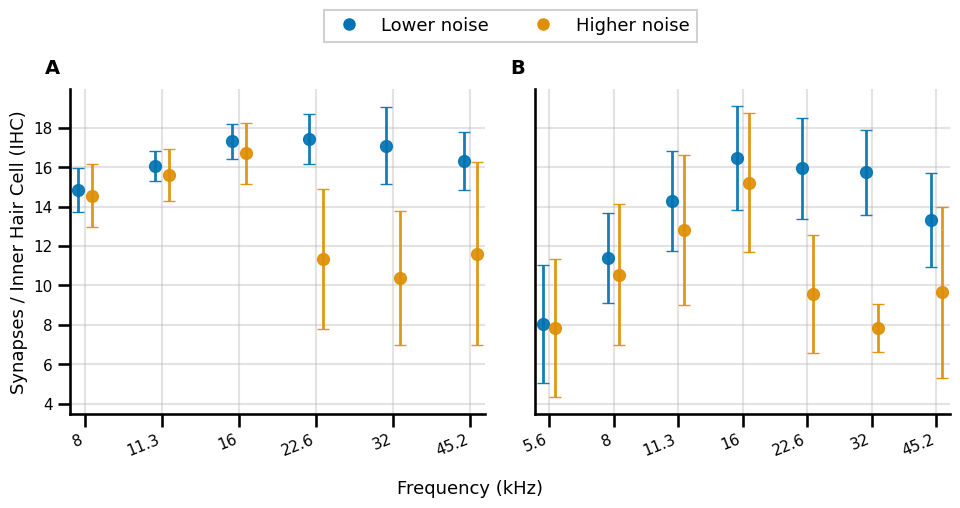

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons_cohorts.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act1_synapse_ribbons_cohorts.svg


In [2]:
_t_ceiling = pd.read_parquet(LIB)
assert len(_t_ceiling) == 1, (
    f"Expected a single aggregate row in {LIB.name}, got {len(_t_ceiling)}. "
    "Re-run liberman_synapses_group_baseline.ipynb export (Group-mean baseline metrics)."
)
ceiling = _t_ceiling.iloc[0]
r2_ceiling = float(ceiling["r2"])
rmse_ceiling = float(ceiling["rmse"])
r2_ceiling_sem = (
    float(ceiling["r2_sem"])
    if "r2_sem" in ceiling.index and pd.notna(ceiling["r2_sem"])
    else None
)
rmse_ceiling_sem = (
    float(ceiling["rmse_sem"])
    if "rmse_sem" in ceiling.index and pd.notna(ceiling["rmse_sem"])
    else None
)
n_cv_folds_ceiling = (
    int(ceiling["n_cv_folds"])
    if "n_cv_folds" in ceiling.index and pd.notna(ceiling["n_cv_folds"])
    else None
)
print("Ceiling headline — parquet:", LIB.resolve())
if rmse_ceiling_sem is not None:
    _nfc_s = (
        f"{n_cv_folds_ceiling}-fold CV"
        if n_cv_folds_ceiling is not None
        else "CV"
    )
    _r2_s = (
        f"{r2_ceiling:.6f}±{r2_ceiling_sem:.6g}"
        if r2_ceiling_sem is not None
        else f"{r2_ceiling:.6f}"
    )
    print(
        f"  R²={_r2_s}  RMSE={rmse_ceiling:.6f}±{rmse_ceiling_sem:.6g}  "
        f"({_nfc_s}, Liberman wide; SEM across folds)"
    )
else:
    print(
        f"  R²={r2_ceiling:.6f}  RMSE={rmse_ceiling:.6f}  "
        "(legacy parquet: no SEM columns — re-run liberman_synapses_group_baseline.ipynb)"
    )

_act1_rc = {
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
}

with plt.rc_context(_act1_rc):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.axis("off")
    _r2_head = f"R² = {r2_ceiling:.3f}"
    if r2_ceiling_sem is not None:
        _r2_head += f" ± {r2_ceiling_sem:.3f}"
    ax.text(0.5, 0.58, _r2_head, ha="center", fontsize=22)
    _rmse_head = f"RMSE = {rmse_ceiling:.3f} synapses/IHC"
    if rmse_ceiling_sem is not None:
        _rmse_head += f" ± {rmse_ceiling_sem:.3f} (SEM)"
    ax.text(0.5, 0.32, _rmse_head, ha="center", fontsize=18)
    fig.tight_layout()
    save_deck_png_svg(fig, "deck_act1_ceiling_headline.png")

    pg = pd.read_parquet(LIB_PG)
    pg = pg.loc[pg["n_test_animal_freq"] >= 2].copy()
    n_all = len(pg)
    if n_all > 25:
        pg = pg.nlargest(25, "rmse").sort_values("rmse", ascending=True)
    else:
        pg = pg.sort_values("rmse", ascending=True)
    fig, ax = plt.subplots(figsize=(7.2, max(5.0, 0.42 * len(pg))))
    y = np.arange(len(pg))
    rmax = float(pg["rmse"].max())
    ax.barh(y, pg["rmse"].values, color="steelblue", edgecolor="0.25")
    ax.set_yticks(y)
    labels = [
        str(g)[:32] + ("…" if len(str(g)) > 32 else "") for g in pg["Group"]
    ]
    ax.set_yticklabels(labels, fontsize=9)
    dx_n = max(0.012 * rmax, 0.02)
    for i, row in enumerate(pg.itertuples()):
        rm = float(row.rmse)
        ax.text(
            rm + dx_n,
            i,
            f"n={int(row.n_test_animal_freq)}",
            va="center",
            ha="left",
            fontsize=8,
        )
    ax.set_xlim(0, rmax + dx_n + max(0.052 * rmax, 0.22))
    ax.set_xlabel("Test RMSE (synapses / IHC)")
    sns.despine(ax=ax)
    fig.tight_layout()
    save_deck_png_svg(fig, "deck_act1_per_group_rmse_bars.png")

    gf = pd.read_parquet(LIB_GF)
    freq_order = sorted(gf["frequency"].unique())
    n_f = len(freq_order)
    f_to_i = {f: i for i, f in enumerate(freq_order)}
    groups = sorted(gf["Group"].astype(str).unique())
    n_groups = len(groups)
    if n_groups <= 1:
        spread = 0.0
    elif n_groups == 2:
        spread = 0.06
    else:
        spread = min(0.92 / n_groups, 0.52)
    offs = (
        np.linspace(-spread / 2, spread / 2, n_groups)
        if n_groups > 1
        else np.array([0.0])
    )
    g_to_off = {g: offs[gi] for gi, g in enumerate(groups)}

    def _pooled_mean_sd(part: pd.DataFrame):
        """Overall mean and SD of synapses at one frequency, pooling strata rows."""
        n = part["n_animal_freq"].astype(float)
        mu = part["mean_synapses"].astype(float)
        sd = part["std_synapses"].replace({np.nan: 0.0}).astype(float)
        N = float(n.sum())
        if N <= 0:
            return float("nan"), float("nan")
        mu_g = float((n * mu).sum() / N)
        if N <= 1:
            return mu_g, float(sd.iloc[0]) if len(sd) else float("nan")
        ss = float(((n - 1) * sd**2 + n * (mu - mu_g) ** 2).sum())
        sd_g = float(np.sqrt(max(ss / (N - 1.0), 0.0)))
        return mu_g, sd_g

    pooled_rows = []
    for f in freq_order:
        part = gf.loc[gf["frequency"].eq(f)]
        m_g, s_g = _pooled_mean_sd(part)
        pooled_rows.append(
            {"frequency": f, "mean_synapses": m_g, "std_synapses": s_g}
        )
    gf_global = pd.DataFrame(pooled_rows)

    fig_w = min(14.0, max(8.0, 0.62 * n_f + 5.0))
    fig_h = min(9.5, max(4.8, 0.42 * n_f + 3.6))

    # Synapse ribbons (±1 SD): one colored series per exposure group / legend
    _blue, _orange = "#1f77b4", "#ff7f0e"
    g_to_color = {}
    for gi, gname in enumerate(groups):
        gs = str(gname).strip()
        if gs in ("0", "0.0"):
            g_to_color[gname] = _blue
        elif gs in ("1", "1.0"):
            g_to_color[gname] = _orange
        else:
            g_to_color[gname] = plt.cm.tab10(gi % 10)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    for gname in groups:
        color = g_to_color[gname]
        sub = gf.loc[gf["Group"].astype(str).eq(gname)]
        for _, r in sub.iterrows():
            bi = float(f_to_i[r["frequency"]])
            x = bi + g_to_off[gname]
            m = float(r["mean_synapses"])
            s = float(r["std_synapses"]) if pd.notna(r["std_synapses"]) else 0.0
            ax.errorbar(
                [x],
                [m],
                yerr=[s],
                fmt="o",
                color=color,
                ecolor=color,
                elinewidth=0.85,
                capsize=2.0,
                markersize=3.8,
                alpha=0.88,
                zorder=3,
            )
        ax.plot([], [], "o", color=color, label=noise_group_legend_label(gname))
    ax.set_xticks(np.arange(n_f))
    ax.set_xticklabels([str(f) for f in freq_order], rotation=22, ha="right")
    ax.set_xlabel("Test frequency (kHz)")
    ax.set_ylabel("Synapses / Inner Hair Cell (IHC)")
    ax.legend(title="Noise exposure group", loc="best", title_fontsize=9)
    ax.margins(x=0.02)
    sns.despine(ax=ax)
    fig.tight_layout(rect=[0, 0.06, 1, 0.96])
    save_deck_png_svg(fig, "deck_act1_synapse_ribbons_by_group.png")
    save_deck_png_svg(fig, "deck_act1_synapse_ribbons.png")

    # Global mean ± pooled SD at each frequency (single series)
    fig_g_w = min(13.5, max(7.5, 0.58 * n_f + 4.8))
    fig_g_h = min(8.8, max(4.6, 0.38 * n_f + 3.3))
    fig_g, ax_g = plt.subplots(figsize=(fig_g_w, fig_g_h))
    xs_g = np.arange(n_f, dtype=float)
    ys_g, err_g = [], []
    for f in freq_order:
        row = gf_global.loc[gf_global["frequency"].eq(f)].iloc[0]
        ys_g.append(float(row["mean_synapses"]))
        err_g.append(
            float(row["std_synapses"]) if pd.notna(row["std_synapses"]) else 0.0
        )
    ax_g.errorbar(
        xs_g,
        ys_g,
        yerr=err_g,
        fmt="o",
        color="0.2",
        ecolor="0.38",
        elinewidth=0.9,
        capsize=2.5,
        markersize=5.0,
        alpha=0.92,
        zorder=3,
    )
    ax_g.set_xticks(xs_g)
    ax_g.set_xticklabels([str(f) for f in freq_order], rotation=22, ha="right")
    ax_g.set_xlabel("Test frequency (kHz)")
    ax_g.set_ylabel("Synapses / Inner Hair Cell (IHC)")
    ax_g.margins(x=0.02)
    sns.despine(ax=ax_g)
    fig_g.tight_layout(rect=[0, 0.06, 1, 0.96])
    save_deck_png_svg(fig_g, "deck_act1_synapse_ribbons_global.png")

    fig_sc, ax_sc = plt.subplots(figsize=(fig_w, fig_h))
    for gname in groups:
        color = g_to_color[gname]
        sub = gf.loc[gf["Group"].astype(str).eq(gname)]
        xs_s, ys_s = [], []
        for _, r in sub.iterrows():
            bi = float(f_to_i[r["frequency"]])
            xs_s.append(bi + g_to_off[gname])
            ys_s.append(float(r["mean_synapses"]))
        if not xs_s:
            continue
        ax_sc.scatter(
            xs_s,
            ys_s,
            s=18,
            c=color,
            edgecolors="0.35",
            linewidths=0.35,
            alpha=0.9,
            zorder=3,
            label=noise_group_legend_label(gname),
        )
    ax_sc.set_xticks(np.arange(n_f))
    ax_sc.set_xticklabels([str(f) for f in freq_order], rotation=22, ha="right")
    ax_sc.set_xlabel("Test frequency (kHz)")
    ax_sc.set_ylabel("Synapses / Inner Hair Cell (IHC)")
    ax_sc.legend(title="Noise exposure group", loc="best", title_fontsize=9)
    ax_sc.margins(x=0.02)
    sns.despine(ax=ax_sc)
    fig_sc.tight_layout(rect=[0, 0.06, 1, 0.96])
    save_deck_png_svg(fig_sc, "deck_act1_synapse_ribbons_scatter.png")

    freq_order2 = sorted(gf["frequency"].unique())
    xi2 = np.arange(len(freq_order2), dtype=float)
    med_v, q1_v, q3_v = [], [], []
    for f in freq_order2:
        s = gf.loc[gf["frequency"].eq(f), "std_synapses"].dropna()
        med_v.append(float(s.median()) if len(s) else float("nan"))
        q1_v.append(float(s.quantile(0.25)) if len(s) else float("nan"))
        q3_v.append(float(s.quantile(0.75)) if len(s) else float("nan"))
    fig, ax = plt.subplots(figsize=(7.0, 4.0))
    ax.plot(xi2, med_v, "o-", color="0.15", lw=2, label="Median across groups")
    ax.fill_between(
        xi2, q1_v, q3_v, color="0.55", alpha=0.28, label="IQR across groups"
    )
    ax.set_xticks(xi2)
    ax.set_xticklabels([str(f) for f in freq_order2], rotation=22, ha="right")
    ax.set_xlabel("Test frequency (kHz), discrete bins")
    ax.set_ylabel(
        "Within-stratum SD\n(synapses / IHC)",
        fontsize=10,
        linespacing=1.25,
    )
    ax.legend(loc="upper left", fontsize=9, framealpha=0.94)
    fig.text(
        0.5,
        0.02,
        "Across experimental groups: spread of animal-level variability within each (Group, frequency) stratum.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=[0.02, 0.11, 0.98, 0.96])
    save_deck_png_svg(fig, "deck_act1_std_median_by_frequency.png")

print(
    "std_synapses quantiles:\n", gf["std_synapses"].quantile([0.25, 0.5, 0.75])
)
idxmax = gf.loc[gf["mean_synapses"].idxmax()]
idxmin = gf.loc[gf["mean_synapses"].idxmin()]
print(
    "max mean_synapses:",
    float(idxmax["mean_synapses"]),
    "Group",
    idxmax["Group"],
    "freq",
    idxmax["frequency"],
)
print(
    "min mean_synapses:",
    float(idxmin["mean_synapses"]),
    "Group",
    idxmin["Group"],
    "freq",
    idxmin["frequency"],
)

from utils.deck_storyline import deck_act1_synapse_ribbons_cohorts

deck_act1_synapse_ribbons_cohorts()

### Speaker script — Act I figures

- **Ceiling headline (I1):** "Liberman test: a **simple rule** that only uses **which noise exposure stratum (`noise_cat` / `Group`)** and **which test frequency** — no ABR. The headline **R²** and **RMSE** (synapses per inner hair cell) summarize how close that rule is on held-out animals."
- **Per-group bars (I2):** "Each bar is how far the **same simple rule** is from held-out **animal×frequency** rows in one **Group**; longer bar = **worse**. The **n** column is how many test rows went into that bar — small **n** means a shakier estimate."
- **Cohort ribbons (I3a, deck):** "`deck_act1_synapse_ribbons_cohorts`: **two panels** — **Cohort A (Liberman)** and **Cohort B (Brad)** — **mean ± 1 SD** per **(noise group × frequency)**; shared legend **Lower noise** / **Higher noise** (threshold in caption, not on-figure)."
- **Strata ribbons by group (legacy single-panel):** "`deck_act1_synapse_ribbons_by_group` (also `deck_act1_synapse_ribbons`): Liberman-only version of the same stratum means."
- **Global ribbons (I3b):** "`deck_act1_synapse_ribbons_global`: at each frequency, **one** marker for the **global mean** pooling all strata (animal-count weighted), with **±1 SD** bars from the pooled summary (**within-stratum** variances plus **between-stratum** mean separation)."
- **Strata scatter (I3c, no SD):** "`deck_act1_synapse_ribbons_scatter` — **mean only**, same **noise exposure group** legend as I3a."
- **Spread vs frequency (I4):** "At each test frequency, bars show **median** within-stratum **SD** across groups; whiskers span **IQR** — how much animal-to-animal spread sits inside each stratum."

_Transitions: **Act Ib** closes the **linear** ladder on Liberman **`C`**; **Act II** then shows **classical** ABR models on the same **RMSE** scale — lower is better._



## Act Ib — Liberman `C` (OLS ladder + Stage 1)

**Order (talk / workbook):** **O1** (two OLS marks) → **IId / IIe** (Stage 1 wide **LR + RF**, animal-level) → **O2** (three noise-only marks) → **O3** (four-mark ladder).

**Exports:** `deck_act2_ols_two_amp_full_liberman_C_RMSE`, `deck_act2_stage1_roc`, `deck_act2_stage1_calibration`, `deck_act2_ols_three_noise_liberman_C_RMSE`, `deck_act2_ols_four_stack_liberman_C_RMSE` — **PNG + SVG** under `figures/presentation/`.

**Data:** `deck_o1_ols_two_marks_liberman.parquet`, `deck_o2_ols_three_noise_marks_liberman.parquet`, `deck_o3_ols_four_stack_marks_liberman.parquet` from **`abr_wide_long_comparison.ipynb`**; `stage1_wide_noise_lr_rf_eval.parquet` from **`abr_stage1_wide.ipynb`**.


=== O1 Liberman OLS (two marks) ===
parquet: /Users/nowaki027/MSDS/Practicum/figures/cache/deck_o1_ols_two_marks_liberman.parquet
 mark        strip_label                                                             predictor_note scenario       r2     rmse
    1   Amp @ 80 dB only                                               single column amplitude_80.0        C 0.228920 3.090075
    2 All ABR (no noise) 92 SPL cols from _SYN_NUM+_SYN_LOG; no noise_cat / target_90 / noise_preds        C 0.347327 2.842936
=== end OLS digest ===


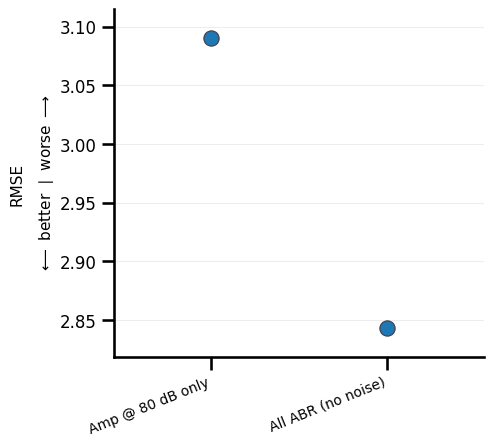

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_ols_two_amp_full_liberman_C_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_ols_two_amp_full_liberman_C_RMSE.svg
=== IId Stage 1 ROC digest (animal-level wide classifier) ===
parquet: /Users/nowaki027/MSDS/Practicum/figures/cache/stage1_wide_noise_lr_rf_eval.parquet
--- Brad --- rows=24 animals=12
  LR: AUC=0.9722
  RF: AUC=0.9444
--- Liberman --- rows=42 animals=21
  LR: AUC=0.9455
  RF: AUC=0.9091
=== end IId ===


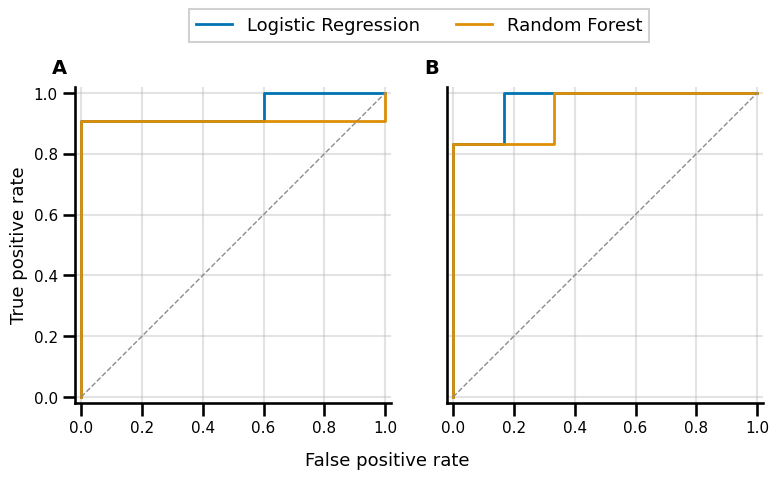

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_stage1_roc.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_stage1_roc.svg
=== IIe Stage 1 calibration digest ===
  Brad LR: n_bins=4 strategy=uniform n=12
  Brad RF: n_bins=4 strategy=uniform n=12
  Liberman LR: n_bins=5 strategy=uniform n=21
  Liberman RF: n_bins=5 strategy=uniform n=21
=== end IIe ===


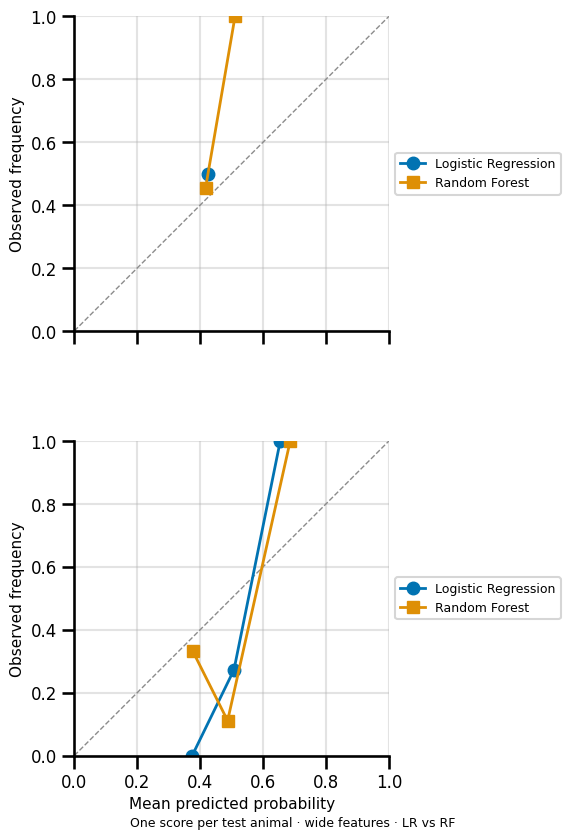

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_stage1_calibration.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_stage1_calibration.svg
=== O2 Liberman OLS (three noise-only marks) ===
parquet: /Users/nowaki027/MSDS/Practicum/figures/cache/deck_o2_ols_three_noise_marks_liberman.parquet
 mark                    strip_label                                                                      predictor_note scenario       r2     rmse
    1      Recorded Noise (SPL) only                                     mean Noise per animal×frequency; no ABR columns        C 0.104239 3.330545
    2      True exposure binary only          C(target_90) with target_90 from noise_cat (Noise<=0.91→0); no ABR columns        C 0.233396 3.081093
    3 Predicted exposure binary only C(noise_preds) Stage‑1 wide RF (same wide ABR feats as IId); OLS uses this col only        C 0.163477 3.218534
=== end OLS digest ===


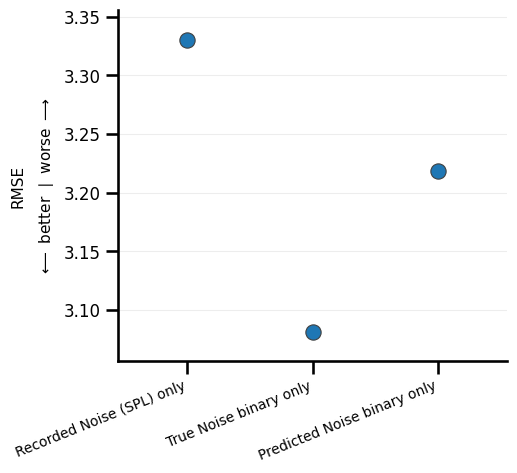

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_ols_three_noise_liberman_C_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_ols_three_noise_liberman_C_RMSE.svg
=== O3 Liberman OLS (four-mark ladder) ===
parquet: /Users/nowaki027/MSDS/Practicum/figures/cache/deck_o3_ols_four_stack_marks_liberman.parquet
 mark                    strip_label                                                            predictor_note scenario       r2     rmse
    1               Amp @ 80 dB only           same as O1 mark 1: Q('amplitude_80.0') only; full Liberman test        C 0.228920 3.090075
    2             All ABR (no noise)             same as O1 mark 2: _SYN_NUM+_SYN_LOG only; full Liberman test        C 0.347327 2.842936
    3 Predicted exposure binary only   same as O2 mark 3: C(noise_preds) only; n=test rows with metadata+preds        C 0.163477 3.218534
    4    Full ABR + predicted binary C(noise_preds)+all _SYN_NUM+_SYN_LOG; test rows with non-null

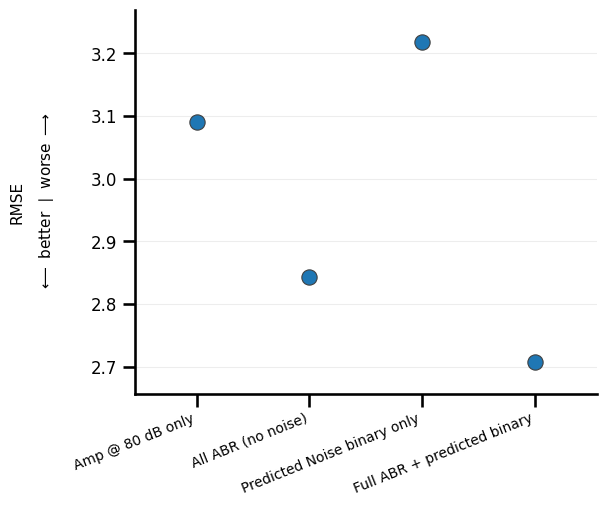

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_ols_four_stack_liberman_C_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_ols_four_stack_liberman_C_RMSE.svg


In [3]:
from utils.deck_storyline import (
    deck_act2_stage1_roc_calibration,
    deck_act_ib_o1_two_marks_liberman,
    deck_act_ib_o2_three_noise_liberman,
    deck_act_ib_o3_four_stack_liberman,
)

deck_act_ib_o1_two_marks_liberman()
deck_act2_stage1_roc_calibration()
deck_act_ib_o2_three_noise_liberman()
deck_act_ib_o3_four_stack_liberman()

## Act II — Classical (RMSE strips)

**Notes:** Brad sparse LR → engineered features → Liberman wide vs long → RF / XGB → Stage 1 noise → LR with vs without Stage 1 (see exported row labels in `classical_benchmark_long.parquet`). **Epilogue (`IIa`):** `deck_act2_classical_brad_B_RMSE` — `test_set=Brad`, `scenario=B` (digest `=== IIa Classical Brad B digest ===`). **Main Liberman (`IIb`):** `deck_act2_classical_liberman_C_RMSE` — Liberman test (in-library training in the export). **Appendix (`IIc`):** `deck_act2_classical_matched_brad_A_RMSE` + `deck_act2_classical_matched_liberman_C_RMSE` — digest `=== IIc Classical matched-training digest ===` + **shared `ylim`** across both exports.

=== IIa Classical Brad B digest ===
parquet: /Users/nowaki027/MSDS/Practicum/figures/cache/classical_benchmark_long.parquet
      model  variant     RMSE       R2
LR baseline all-long 4.300470 0.179224
LR baseline all-wide 3.755672 0.374009
    LR full all-long 3.248023 0.531801
    LR full all-wide 4.694957 0.021736
         RF all-long 4.161493 0.231416
         RF all-wide 3.458378 0.469192
        XGB all-long 4.024446 0.281205
        XGB all-wide 3.215693 0.541075
n_rows: 8
=== end IIa ===


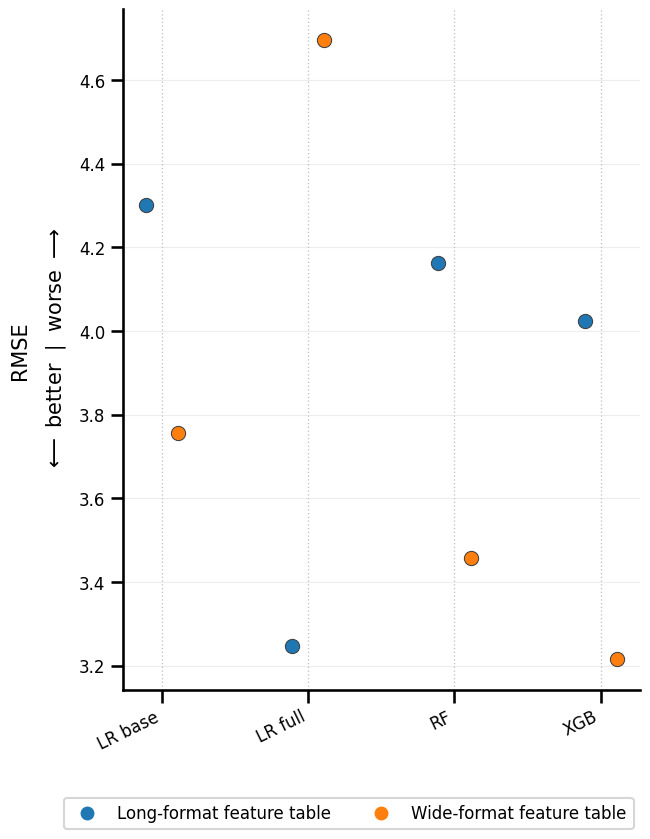

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_classical_brad_B_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_classical_brad_B_RMSE.svg
=== IIb Classical Liberman digest ===
parquet: /Users/nowaki027/MSDS/Practicum/figures/cache/classical_benchmark_long.parquet
      model  variant     RMSE        R2
LR baseline all-long 3.700824 -0.019006
LR baseline all-wide 3.090075  0.228920
    LR full all-long 2.937254  0.358106
    LR full all-wide 2.477811  0.504210
         RF all-long 2.592166  0.500074
         RF all-wide 2.252370  0.590323
        XGB all-long 2.675361  0.467469
        XGB all-wide 2.165494  0.621317
n_rows: 8
=== end IIb ===


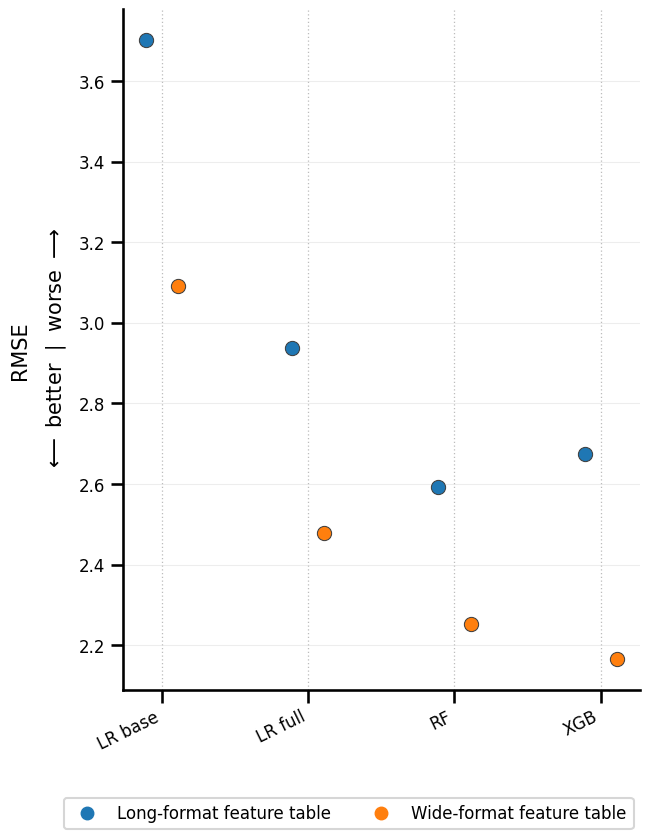

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_classical_liberman_C_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_classical_liberman_C_RMSE.svg
=== IIc Classical matched-training digest ===
parquet: /Users/nowaki027/MSDS/Practicum/figures/cache/classical_benchmark_long.parquet
--- Brad test, train A ---
      model  variant     RMSE       R2
LR baseline all-long 4.300470 0.179224
LR baseline all-wide 3.755672 0.374009
    LR full all-long 3.248023 0.531801
    LR full all-wide 4.694957 0.021736
         RF all-long 3.127552 0.565888
         RF all-wide 3.381246 0.492605
        XGB all-long 3.105539 0.571977
        XGB all-wide 3.385561 0.491309
  n_rows: 8
--- Liberman test, train C ---
      model  variant     RMSE        R2
LR baseline all-long 3.700824 -0.019006
LR baseline all-wide 3.090075  0.228920
    LR full all-long 2.937254  0.358106
    LR full all-wide 2.477811  0.504210
         RF all-long 2.592166  0.500074
         RF

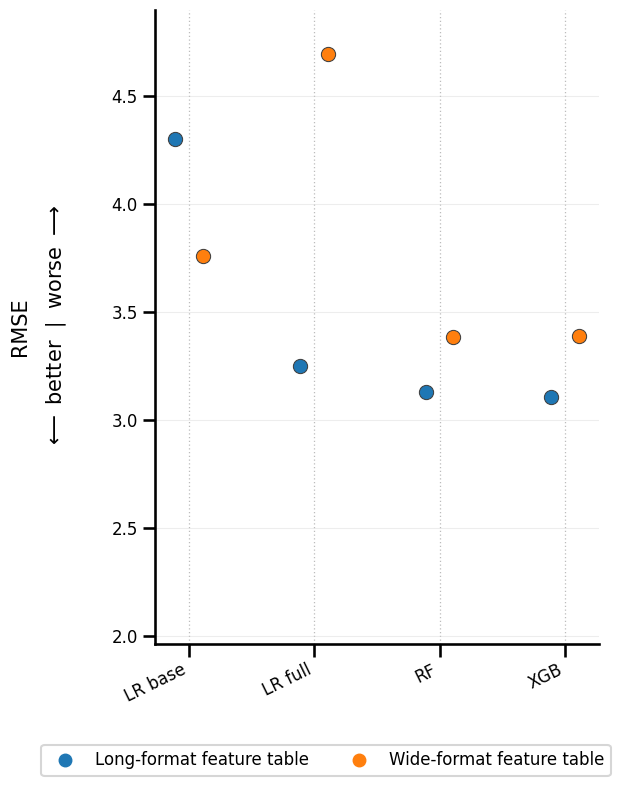

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_classical_matched_brad_A_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_classical_matched_brad_A_RMSE.svg


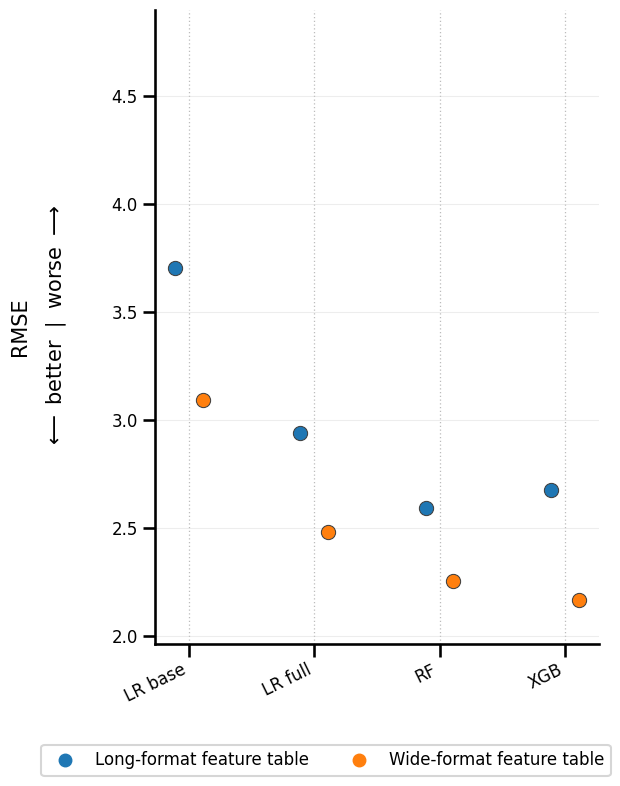

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_classical_matched_liberman_C_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act2_classical_matched_liberman_C_RMSE.svg
IIc shared ylim (P2b): (1.9631, 4.8973)
=== Act II recap: LR RMSE (Liberman in-library vs Brad transfer) ===
Liberman  trainC  LR baseline   all-long   RMSE=3.7008
Liberman  trainC  LR baseline   all-wide   RMSE=3.0901
Liberman  trainC  LR full       all-long   RMSE=2.9373
Liberman  trainC  LR full       all-wide   RMSE=2.4778
Brad  trainB  LR baseline   all-long   RMSE=4.3005
Brad  trainB  LR baseline   all-wide   RMSE=3.7557
Brad  trainB  LR full       all-long   RMSE=3.2480
Brad  trainB  LR full       all-wide   RMSE=4.6950


In [4]:
cl = pd.read_parquet(CL)


def classical_panel(test_set: str, scenario: str, fname: str) -> None:
    sub = filter_classical(cl)
    sub = sub.loc[sub["test_set"].eq(test_set) & sub["scenario"].eq(scenario)]
    if test_set == "Liberman" and scenario == "C":
        print("=== IIb Classical Liberman digest ===")
        print("parquet:", CL.resolve())
        if sub.empty:
            print(
                "WARNING: no classical rows for Liberman test (check classical export)."
            )
        else:
            _show = [
                c
                for c in ("model", "variant", "RMSE", "R2")
                if c in sub.columns
            ]
            print(
                sub[_show]
                .sort_values(["model", "variant"])
                .to_string(index=False)
            )
            print("n_rows:", len(sub))
        print("=== end IIb ===")
    elif test_set == "Brad" and scenario == "B":
        print("=== IIa Classical Brad B digest ===")
        print("parquet:", CL.resolve())
        if sub.empty:
            print(
                "WARNING: no rows for Brad test, scenario B — confirm P0.5 "
                "(typical: train Liberman → test Brad) in classical export."
            )
        else:
            _show = [
                c
                for c in ("model", "variant", "RMSE", "R2")
                if c in sub.columns
            ]
            print(
                sub[_show]
                .sort_values(["model", "variant"])
                .to_string(index=False)
            )
            print("n_rows:", len(sub))
        print("=== end IIa ===")
    fig, ax = plt.subplots(figsize=(6.2, 9.2))
    scatter_classical_rmse(ax, sub)
    add_long_wide_variant_legend(fig)
    fig.subplots_adjust(left=0.135, right=0.97, top=0.92, bottom=0.18)
    save_deck_png_svg(fig, fname)


classical_panel("Brad", "B", "deck_act2_classical_brad_B_RMSE.png")
classical_panel("Liberman", "C", "deck_act2_classical_liberman_C_RMSE.png")

_pairs_iic = (("Brad", "A"), ("Liberman", "C"))
print("=== IIc Classical matched-training digest ===")
print("parquet:", CL.resolve())
for _ts, _sc in _pairs_iic:
    _sub_i = filter_classical(cl)
    _sub_i = _sub_i.loc[_sub_i["test_set"].eq(_ts) & _sub_i["scenario"].eq(_sc)]
    print(f"--- {_ts} test, train {_sc} ---")
    if _sub_i.empty:
        print("  WARNING: empty classical slice.")
    else:
        _show_i = [
            c for c in ("model", "variant", "RMSE", "R2") if c in _sub_i.columns
        ]
        print(
            _sub_i[_show_i]
            .sort_values(["model", "variant"])
            .to_string(index=False)
        )
        print("  n_rows:", len(_sub_i))
print("=== end IIc ===")

_order4 = list(BENCHMARK_DISPLAY_ORDER[:4])
_ys: list[float] = []
for ts, sc in _pairs_iic:
    sub_m = filter_classical(cl)
    sub_m = sub_m.loc[sub_m["test_set"].eq(ts) & sub_m["scenario"].eq(sc)]
    cls_m = sub_m[sub_m["model"].isin(_order4)]
    if not cls_m.empty:
        _ys.extend(cls_m["RMSE"].astype(float).tolist())
if _ys:
    _sp = max(_ys) - min(_ys)
    _pad = 0.08 * _sp if _sp > 0 else 0.1
    _y0, _y1 = min(_ys) - _pad, max(_ys) + _pad
else:
    _y0, _y1 = 0.0, 1.0

for ts, sc in _pairs_iic:
    sub = filter_classical(cl)
    sub = sub.loc[sub["test_set"].eq(ts) & sub["scenario"].eq(sc)]
    fig_i, ax_i = plt.subplots(figsize=(5.8, 8.8))
    scatter_classical_rmse(
        ax_i,
        sub,
        rmse_label_x=-0.26,
    )
    ax_i.set_ylim(_y0, _y1)
    add_long_wide_variant_legend(fig_i)
    fig_i.subplots_adjust(left=0.205, right=0.97, top=0.90, bottom=0.18)
    if ts == "Brad":
        save_deck_png_svg(fig_i, "deck_act2_classical_matched_brad_A_RMSE.png")
    else:
        save_deck_png_svg(
            fig_i, "deck_act2_classical_matched_liberman_C_RMSE.png"
        )
print(f"IIc shared ylim (P2b): ({_y0:.4f}, {_y1:.4f})")

# --- Recap numbers for bridge (cache only; no new fits) ---
_cl_recap = pd.read_parquet(CL)
_rec = filter_classical(_cl_recap)
print("=== Act II recap: LR RMSE (Liberman in-library vs Brad transfer) ===")
for _ts, _sc in (("Liberman", "C"), ("Brad", "B")):
    _sub = _rec.loc[_rec["test_set"].eq(_ts) & _rec["scenario"].eq(_sc)]
    for _m in ("LR baseline", "LR full"):
        for _v in ("all-long", "all-wide"):
            _r = _sub.loc[
                _sub["model"].eq(_m) & _sub["variant"].astype(str).eq(_v),
                "RMSE",
            ]
            _val = float(_r.iloc[0]) if len(_r) else float("nan")
            print(f"{_ts}  train{_sc}  {_m:12s}  {_v:9s}  RMSE={_val:.4f}")

### Speaker script — Act II (classical + Stage 1)

- **Brad (`IIa`) and Liberman (`IIb`) strips:** "Each **dot** is **test RMSE** at **animal×frequency** — how far off predictions are in **synapses per IHC**, on average. **Long** vs **wide** feature tables are the **two dot colors** (see figure legend). **Lower is better** on the vertical axis."
- **Matched appendix (`IIc`):** Two **separate** figures (**Brad** + **Liberman**) with the **same vertical scale** — **Brad** models trained only on **Brad**, **Liberman** in-library — a **matched-cohort** sanity check; read **`IIc shared ylim`** in the notebook printout."
- **Stage 1 ROC + calibration:** "These export from the **Act Ib** cell (`deck_act2_stage1_roc`, `deck_act2_stage1_calibration`). Two **wide** classifiers — **Logistic Regression (LR)** and **Random Forest (RF)** — guess **noise condition** from ABR pivots — **animal-level** scores so we don't cheat by double-counting ears. **ROC**: **higher curve** = better separation; read **AUC** in the legend; **sample size** is the legend title (**n** test animals, held-out). **Calibration**: **on the diagonal** means predicted probabilities match observed frequencies."
- **Recap numbers:** "Use the **printed table** from the code cell (`=== Act II recap ===`) — read **LR baseline vs LR full** RMSEs **out loud** for Liberman then Brad."

_Next: Act III isolates **deep models** without the four classical slots._



## Act II → III bridge

- Wide vs long: two hues on strips.
- Stage 1: noise-from-ABR beat.
- LR ± Stage1: compare RMSE in exported rows (Notes).

## Act III — NN focus, then three-way compare

**Outputs:** **`deck_act3_nn_only_liberman_C_RMSE`** + **`deck_act3_compare_best_per_family_liberman_C_RMSE`** (Liberman test); Brad epilogue uses **`deck_act3_nn_only_brad_B_RMSE`** + **`deck_act3_compare_best_per_family_brad_B_RMSE`**. **PNG + SVG** via `save_deck_png_svg` (workbook policy).

**Notes — CNN:** both cohorts use **Liberman-matched** crop length / timebase (`RunConfig` / `full_wave_ref`); do **not** treat Lib vs Brad trace length as a comparability axis in the live talk.

=== IIIa Liberman NN-only digest ===
          model variant   RMSE     R2
   CNN (Wave I)    <NA> 2.7941 0.4192
CNN (full wave)    <NA> 2.7857 0.4226
            MLP    <NA> 2.8769 0.3842
n_nn_rows: 3
=== end IIIa ===


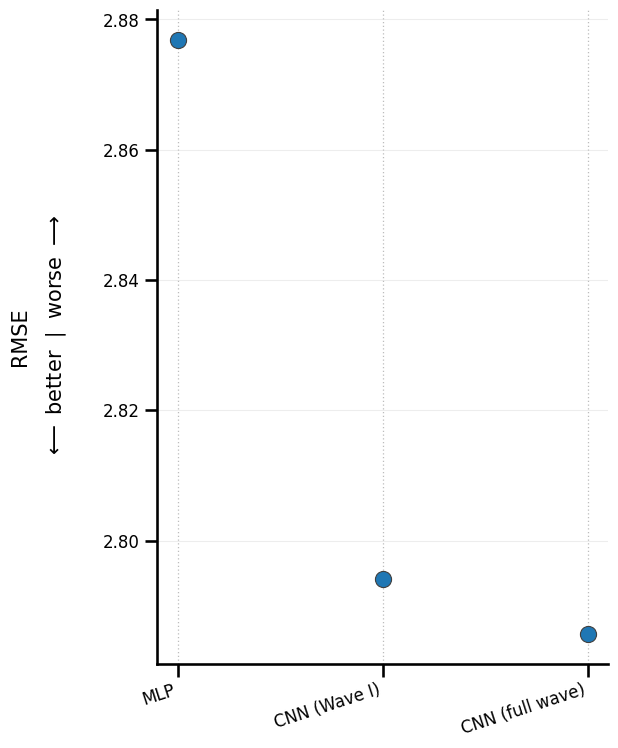

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act3_nn_only_liberman_C_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act3_nn_only_liberman_C_RMSE.svg
=== IIIc Liberman best-per-family digest ===
  linear: RMSE=2.47781  model=LR full  variant=all-wide  (min over long+wide where applicable)
  tree: RMSE=2.16549  model=XGB  variant=all-wide  (min over long+wide where applicable)
  neural: RMSE=2.7857  model=CNN (full wave)  variant=<NA>  (min over long+wide where applicable)
=== end IIIc ===


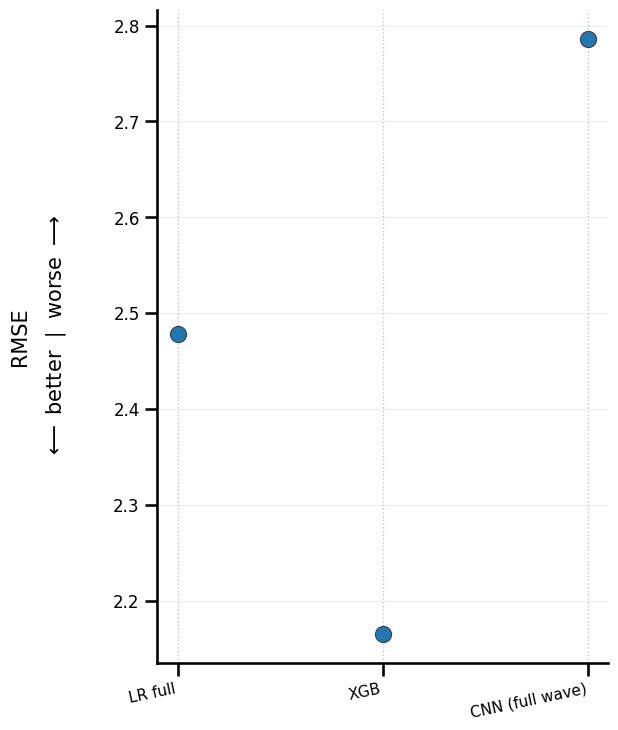

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act3_compare_best_per_family_liberman_C_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act3_compare_best_per_family_liberman_C_RMSE.svg
=== IIIb Brad NN-only digest (train Liberman → Brad) ===
          model variant   RMSE     R2
   CNN (Wave I)    <NA> 3.0711 0.5814
CNN (full wave)    <NA> 3.1517 0.5592
            MLP    <NA> 3.0508 0.5869
n_nn_rows: 3
=== end IIIb ===


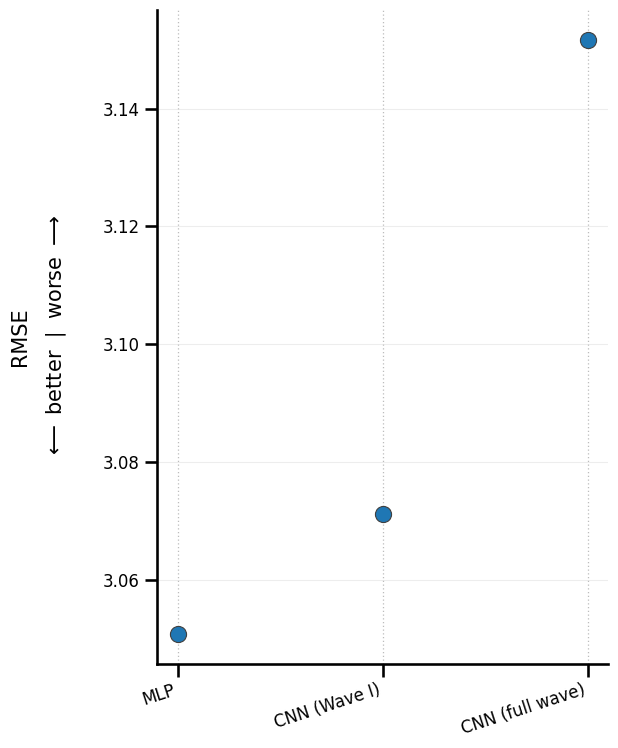

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act3_nn_only_brad_B_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act3_nn_only_brad_B_RMSE.svg
=== IIId Brad best-per-family digest ===
  linear: RMSE=3.24802  model=LR full  variant=all-long  (min over long+wide where applicable)
  tree: RMSE=3.21569  model=XGB  variant=all-wide  (min over long+wide where applicable)
  neural: RMSE=3.0508  model=MLP  variant=<NA>  (min over long+wide where applicable)
=== end IIId ===


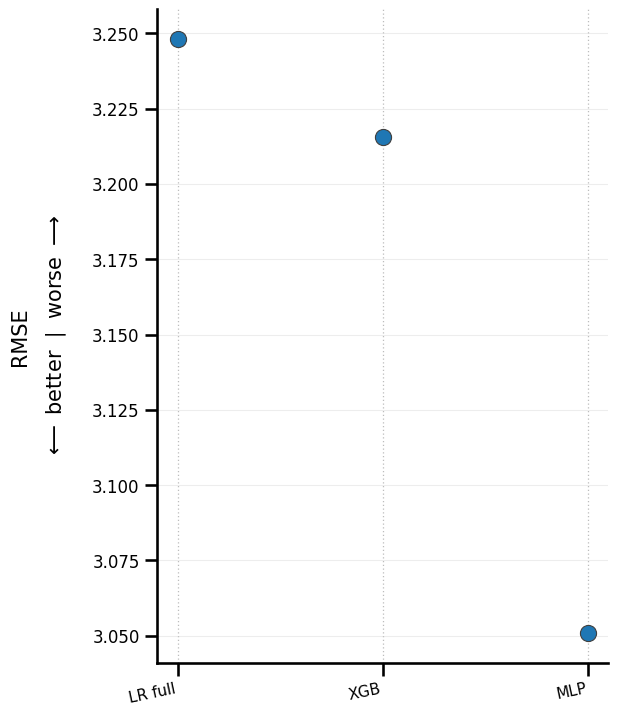

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act3_compare_best_per_family_brad_B_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act3_compare_best_per_family_brad_B_RMSE.svg


In [5]:
VARIANTS_LW = ("all-long", "all-wide")
LINEAR_MODELS = ("LR baseline", "LR full")
TREE_MODELS = ("RF", "XGB")
NN_MODELS = ("MLP", "CNN (Wave I)", "CNN (full wave)")


def _best_rmse_row(
    frame: pd.DataFrame,
    models: tuple[str, ...],
    variants: tuple[str, ...] | None,
) -> pd.Series | None:
    m = frame["model"].isin(models)
    sub = frame.loc[m]
    if variants is not None:
        sub = sub.loc[sub["variant"].astype(str).isin(variants)]
    if sub.empty:
        return None
    idx = sub["RMSE"].astype(float).idxmin()
    return sub.loc[idx]


if benchmark_df is None or not NNP.exists():
    print("Skip Act III NN panels: merged benchmarks unavailable")
else:
    for ts in ("Liberman", "Brad"):
        slug = "liberman" if ts == "Liberman" else "brad"
        _scen = "C" if ts == "Liberman" else "B"
        sub = benchmark_df.loc[
            benchmark_df["test_set"].eq(ts) & benchmark_df["scenario"].eq(_scen)
        ]
        nn = sub.loc[sub["source"].eq("nn")]
        if ts == "Liberman":
            print("=== IIIa Liberman NN-only digest ===")
            if nn.empty:
                print("WARNING: no NN rows for Liberman test")
            else:
                _nc = [
                    c
                    for c in ("model", "variant", "RMSE", "R2")
                    if c in nn.columns
                ]
                print(
                    nn[_nc]
                    .sort_values(["model", "variant"])
                    .to_string(index=False)
                )
                print("n_nn_rows:", len(nn))
            print("=== end IIIa ===")
        elif ts == "Brad":
            print("=== IIIb Brad NN-only digest (train Liberman → Brad) ===")
            if nn.empty:
                print("WARNING: no NN rows for Brad test")
            else:
                _nc = [
                    c
                    for c in ("model", "variant", "RMSE", "R2")
                    if c in nn.columns
                ]
                print(
                    nn[_nc]
                    .sort_values(["model", "variant"])
                    .to_string(index=False)
                )
                print("n_nn_rows:", len(nn))
            print("=== end IIIb ===")
        fig, ax = plt.subplots(figsize=(5.9, 8.6))
        nn_models = ("MLP", "CNN (Wave I)", "CNN (full wave)")
        for xi, mname in enumerate(nn_models):
            hit = nn.loc[nn["model"].eq(mname)]
            if hit.empty:
                continue
            ax.scatter(
                xi,
                float(hit.iloc[0]["RMSE"]),
                s=135,
                c=NN_ALL_LONG_FACE,
                edgecolors="0.25",
                lw=0.8,
                zorder=8,
            )
        apply_benchmark_grid(ax, n_models=3)
        ax.set_xticks(range(3))
        ax.set_xticklabels(
            ["MLP", "CNN (Wave I)", "CNN (full wave)"], rotation=18, ha="right"
        )
        set_rmse_y_margin_label(ax, label_x=-0.26)
        sns.despine(ax=ax)
        fig.subplots_adjust(left=0.205, right=0.97, top=0.88, bottom=0.12)
        save_deck_png_svg(fig, f"deck_act3_nn_only_{slug}_{_scen}_RMSE.png")

        fig2, ax2 = plt.subplots(figsize=(5.9, 8.6))
        cl = sub.loc[sub["source"].eq("classical")]
        r_lin = _best_rmse_row(cl, LINEAR_MODELS, VARIANTS_LW)
        r_tree = _best_rmse_row(cl, TREE_MODELS, VARIANTS_LW)
        r_nn = _best_rmse_row(nn, NN_MODELS, None)
        slots = [(0, "linear", r_lin), (1, "tree", r_tree), (2, "neural", r_nn)]
        tick_labels: list[str] = []
        if ts == "Liberman":
            print("=== IIIc Liberman best-per-family digest ===")
        else:
            print("=== IIId Brad best-per-family digest ===")
        for xi, fam, row in slots:
            if row is None:
                tick_labels.append("—")
                print(f"  {fam}: MISSING")
                continue
            mod = str(row["model"])
            rm = float(row["RMSE"])
            ax2.scatter(
                xi,
                rm,
                s=135,
                c=NN_ALL_LONG_FACE,
                edgecolors="0.25",
                lw=0.8,
                zorder=6,
            )
            tick_labels.append(mod)
            _var = row.get("variant", "")
            print(
                f"  {fam}: RMSE={rm:.6g}  model={mod}  variant={_var}  (min over long+wide where applicable)"
            )
        if ts == "Liberman":
            print("=== end IIIc ===")
        else:
            print("=== end IIId ===")
        apply_benchmark_grid(ax2, n_models=3)
        ax2.set_xticks(range(3))
        ax2.set_xticklabels(tick_labels, fontsize=11, rotation=12, ha="right")
        set_rmse_y_margin_label(ax2, label_x=-0.26)
        sns.despine(ax=ax2)
        fig2.subplots_adjust(left=0.205, right=0.97, top=0.88, bottom=0.12)
        save_deck_png_svg(
            fig2, f"deck_act3_compare_best_per_family_{slug}_{_scen}_RMSE.png"
        )

### Speaker script — Act III (NN-only, then three-way)

- **C7a NN-only (Liberman main):** "**Liberman** test. Only **MLP** on pivoted wide rows and the two **CNN** traces — **Liberman-matched** timebase. Same RMSE axis convention: **lower is better**."
- **C7a′ Brad epilogue (optional):** "**Brad** test, **train `B`** (**transfer**). Same three NN marks as **IIIa**; read **`=== IIIb Brad NN-only digest (scenario B) ===`** ↔ **`deck_act3_nn_only_brad_B_RMSE`** — name **P0.5** in speech (transfer vs in-library); do not imply head-to-head vs **IIIa** without naming the scenario shift."
- **C7b Best per family:** "**Three** points: **best linear** (lowest RMSE among LR baseline / LR full over long and wide tables), **best tree** (RF vs XGB, same rule), and **best neural** (MLP vs CNNs) — **same** test slice as the NN-only strip (Liberman in-library; Brad transfer)."
- **C7b′ Brad epilogue (optional):** **`=== IIId Brad best-per-family digest ===`** ↔ **`deck_act3_compare_best_per_family_brad_B_RMSE`** — winning **MLP** row must match **IIIb** on the same **`sub`**; CNNs stay on **IIIb** only."

_Act IV puts the **full stack** back with **ceiling** reference lines._



## Act IV — Synthesis (RMSE + ceilings)

**Notes:** headline panels are **RMSE-only**; ceiling lines are **reference** (expected gap vs ABR), not a win target.

**Exports:** Liberman test and Brad test each get **three** synthesis figures for train scenarios **`A` / `B` / `C`**: `deck_act4_synthesis_liberman_{A,B,C}_RMSE` and `deck_act4_synthesis_brad_{A,B,C}_RMSE` (**PNG+SVG**). **Combined:** **`deck_act4_synthesis_grid_RMSE`** — **2×3** subplot grid (rows **Brad test** then **Liberman test**, columns **Training scenario A/B/C**); **`sharey='row'`** so Brad and Liberman vertical scales float separately; ceiling band unchanged per cohort. The **ceiling** band is the same Liberman noise_cat×frequency and Brad noise_cat×frequency cohort baselines across scenarios; only the model **RMSE** marks change with the training slice.

### Brad native ceiling (Notes)

**Ceiling on Brad wide:** **10-fold `StratifiedGroupKFold` CV** stratified by **`experimental_group`** (Brad **`tx`**, Liberman **`Group`**), grouped by **`animal_id`**; each fold predicts mean synapses per **`noise_cat`×`frequency`** from train animals (§5.2 / model strata). Output: **`figures/cache/brad_group_mean_baseline_metrics.parquet`** (`r2`, `r2_sem`, `rmse`, `rmse_sem`, `n_cv_folds`).

In [6]:
from utils.subject_cv import (
    DEFAULT_CEILING_CV_RANDOM_STATE,
    DEFAULT_CEILING_CV_SPLITS,
    eval_stratum_mean_baseline_cv,
)

N_FOLDS = DEFAULT_CEILING_CV_SPLITS
RNG = DEFAULT_CEILING_CV_RANDOM_STATE

_data = load_nn_stage2_data()
_sp = splits_for_long_stage2(_data)
bb_tr = _sp["bb_wide_train"].copy()
bb_te = _sp["bb_wide_test"].copy()
bb_full = pd.concat([bb_tr, bb_te], ignore_index=True)

_cv_out = eval_stratum_mean_baseline_cv(
    bb_full,
    ["noise_cat", "frequency"],
    n_splits=N_FOLDS,
    random_state=RNG,
)
rmse_brad_ceiling = _cv_out["rmse"]
rmse_brad_ceiling_sem = _cv_out["rmse_sem"]
r2_brad_ceiling = _cv_out["r2"]
r2_brad_ceiling_sem = _cv_out["r2_sem"]
print(
    f"Brad noise_cat×frequency ceiling — {N_FOLDS}-fold StratifiedGroupKFold CV: "
    f"R² = {r2_brad_ceiling:.4f} ± {r2_brad_ceiling_sem:.4f} (SEM), "
    f"RMSE = {rmse_brad_ceiling:.4f} ± {rmse_brad_ceiling_sem:.4f} (SEM)"
)

brad_ceiling_path = CACHE_DIR / "brad_group_mean_baseline_metrics.parquet"
pd.DataFrame(
    [
        {
            "r2": r2_brad_ceiling,
            "r2_sem": r2_brad_ceiling_sem,
            "rmse": rmse_brad_ceiling,
            "rmse_sem": rmse_brad_ceiling_sem,
            "n_cv_folds": _cv_out["n_cv_folds"],
        }
    ]
).to_parquet(brad_ceiling_path, index=False)
print("Saved", brad_ceiling_path.resolve())
assert (
    rmse_brad_ceiling > 0 and rmse_brad_ceiling < 1e6
), "sanity: Brad ceiling RMSE"

Brad noise_cat×frequency ceiling — 10-fold StratifiedGroupKFold CV: R² = 0.4798 ± 0.0388 (SEM), RMSE = 2.9616 ± 0.1496 (SEM)
Saved /Users/nowaki027/MSDS/Practicum/figures/cache/brad_group_mean_baseline_metrics.parquet


=== IVa Liberman synthesis digest (scenario A) ===
  slice: test_set=Liberman scenario=A n_classical=3 n_nn=1 ceiling_RMSE=2.34197 ± 0.0987528 (SEM)
      model  variant    source     RMSE        R2
LR baseline all-wide classical 3.090075  0.228920
         RF all-wide classical 3.187205  0.179683
        XGB all-long classical 3.230287  0.223641
        MLP     <NA>        nn 4.757200 -0.683700
=== end IVa ===


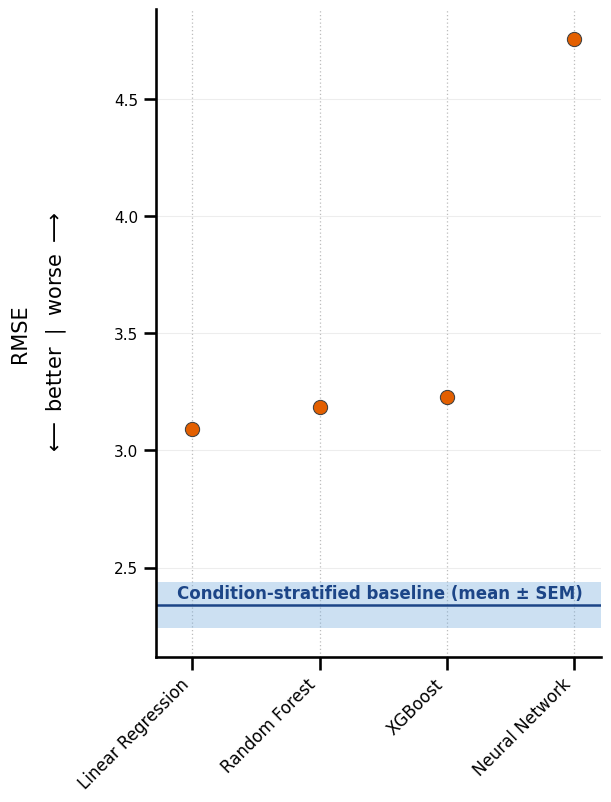

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_liberman_A_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_liberman_A_RMSE.svg
=== IVa Liberman synthesis digest (scenario B) ===
  slice: test_set=Liberman scenario=B n_classical=3 n_nn=1 ceiling_RMSE=2.34197 ± 0.0987528 (SEM)
      model  variant    source     RMSE       R2
LR baseline all-wide classical 3.090075 0.228920
         RF all-wide classical 2.446095 0.516821
        XGB all-wide classical 2.340365 0.557688
        MLP     <NA>        nn 2.984300 0.337400
=== end IVa ===


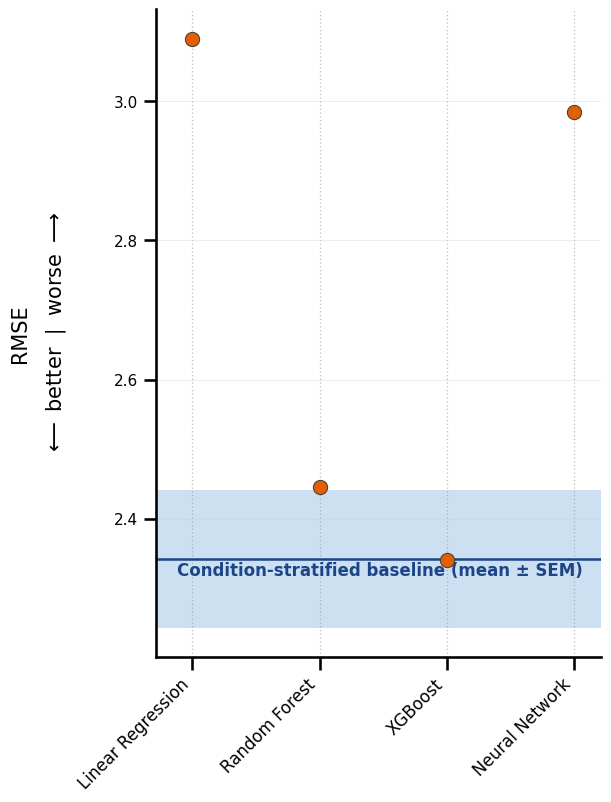

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_liberman_B_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_liberman_B_RMSE.svg
=== IVa Liberman synthesis digest (scenario C) ===
  slice: test_set=Liberman scenario=C n_classical=3 n_nn=1 ceiling_RMSE=2.34197 ± 0.0987528 (SEM)
      model  variant    source     RMSE       R2
LR baseline all-wide classical 3.090075 0.228920
         RF all-wide classical 2.252370 0.590323
        XGB all-wide classical 2.165494 0.621317
        MLP     <NA>        nn 2.876900 0.384200
=== end IVa ===


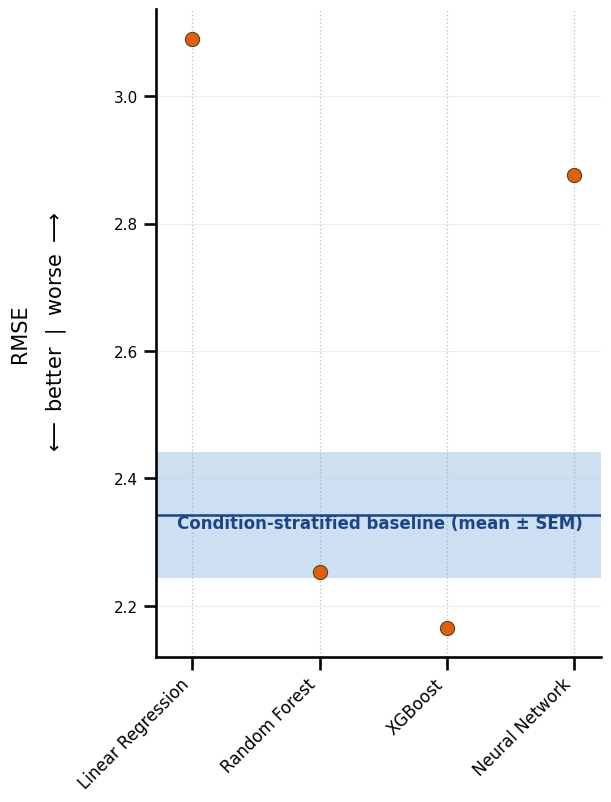

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_liberman_C_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_liberman_C_RMSE.svg
=== IVb Brad synthesis digest (scenario A) ===
  slice: test_set=Brad scenario=A n_classical=3 n_nn=1 ceiling_RMSE=2.96163 ± 0.149565 (SEM)
      model  variant    source     RMSE       R2
LR baseline all-wide classical 3.755672 0.374009
         RF all-long classical 3.127552 0.565888
        XGB all-long classical 3.105539 0.571977
        MLP     <NA>        nn 3.331600 0.507400
=== end IVb ===


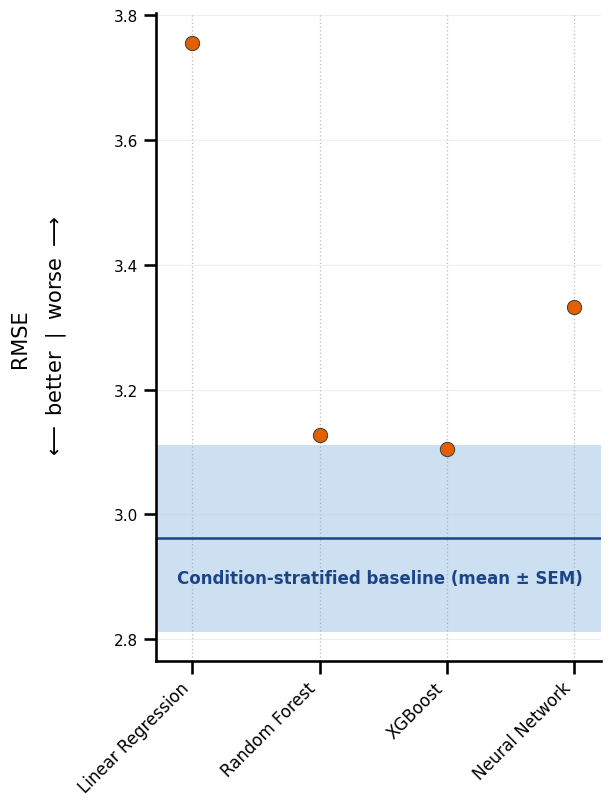

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_brad_A_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_brad_A_RMSE.svg
=== IVb Brad synthesis digest (scenario B) ===
  slice: test_set=Brad scenario=B n_classical=3 n_nn=1 ceiling_RMSE=2.96163 ± 0.149565 (SEM)
      model  variant    source     RMSE       R2
LR baseline all-wide classical 3.755672 0.374009
         RF all-wide classical 3.458378 0.469192
        XGB all-wide classical 3.215693 0.541075
        MLP     <NA>        nn 3.050800 0.586900
=== end IVb ===


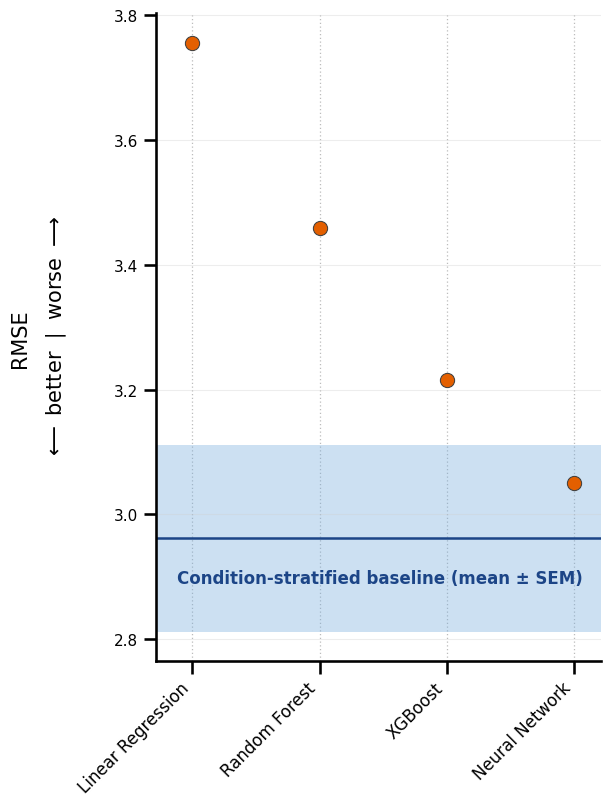

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_brad_B_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_brad_B_RMSE.svg
=== IVb Brad synthesis digest (scenario C) ===
  slice: test_set=Brad scenario=C n_classical=3 n_nn=1 ceiling_RMSE=2.96163 ± 0.149565 (SEM)
      model  variant    source     RMSE        R2
LR baseline all-wide classical 3.755672  0.374009
         RF all-long classical 5.530169 -0.357281
        XGB all-long classical 5.516553 -0.350605
        MLP     <NA>        nn 5.570300 -0.377100
=== end IVb ===


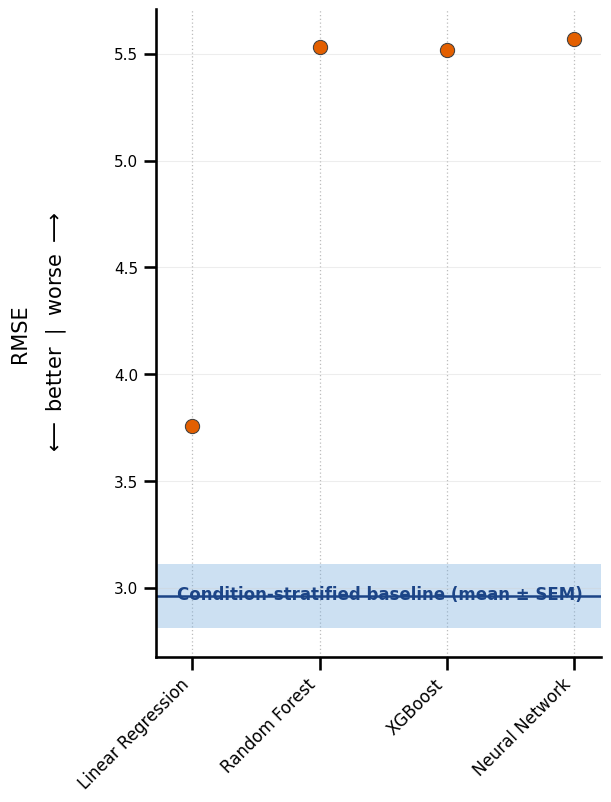

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_brad_C_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_brad_C_RMSE.svg


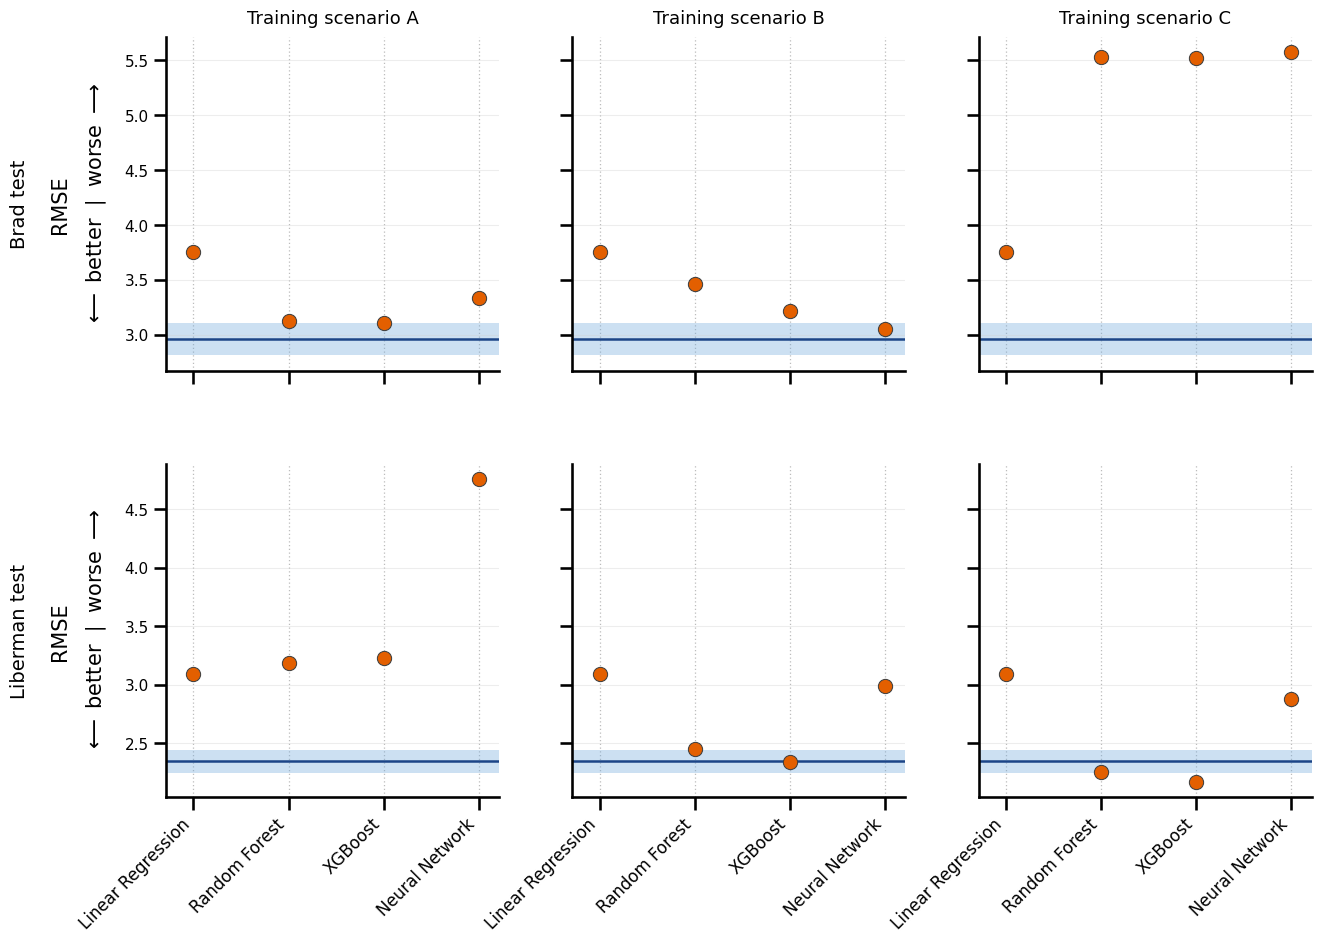

Saved /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_grid_RMSE.png + /Users/nowaki027/MSDS/Practicum/figures/presentation/deck_act4_synthesis_grid_RMSE.svg


In [7]:
ACT4_SYNTHESIS_MODELS: tuple[str, ...] = ("LR baseline", "RF", "XGB", "MLP")
ACT4_SYNTHESIS_LABELS: tuple[str, ...] = (
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "Neural Network",
)
ACT4_X_POSITIONS: tuple[float, ...] = (0.0, 2.6, 5.2, 7.8)
ACT4_MODEL_X: dict[str, float] = dict(
    zip(ACT4_SYNTHESIS_MODELS, ACT4_X_POSITIONS)
)


def _act4_axes_grid(ax, x_positions: tuple[float, ...]) -> None:
    ax.set_axisbelow(True)
    ax.grid(
        True,
        axis="y",
        alpha=0.38,
        linestyle="-",
        linewidth=0.75,
        color="0.82",
        zorder=0,
    )
    for xv in x_positions:
        ax.axvline(
            xv,
            color="0.70",
            linewidth=0.9,
            linestyle=(0, (1, 2)),
            alpha=0.88,
            zorder=0,
        )


def _act4_draw_ceiling(
    ax,
    ceiling_rmse: float,
    ceiling_rmse_sem: float | None,
    *,
    annotate: bool = True,
) -> None:
    band_color = "#6FA8DC"
    line_color = "#1c4587"
    short_baseline = "Condition-stratified baseline (mean ± SEM)"
    has_sem = ceiling_rmse_sem is not None and ceiling_rmse_sem > 0
    if has_sem:
        y_lo = float(ceiling_rmse - ceiling_rmse_sem)
        y_hi = float(ceiling_rmse + ceiling_rmse_sem)
        ax.axhspan(
            y_lo,
            y_hi,
            facecolor=band_color,
            edgecolor="none",
            alpha=0.35,
            zorder=0,
            clip_on=True,
        )
        ax.axhline(ceiling_rmse, color=line_color, ls="-", lw=1.8, zorder=1)
    else:
        line_color = "#555555"
        ax.axhline(ceiling_rmse, color=line_color, ls="--", lw=1.6, zorder=1)
    if not annotate:
        return
    x_right = float(ACT4_X_POSITIONS[-1]) + 0.42
    if has_sem:
        y_lo = float(ceiling_rmse - ceiling_rmse_sem)
        ax.annotate(
            short_baseline,
            xy=(x_right - 0.25, y_lo + 0.05),
            xytext=(0, 10),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color=line_color,
            zorder=11,
            clip_on=False,
        )
    else:
        ax.annotate(
            short_baseline,
            xy=(x_right, float(ceiling_rmse)),
            xytext=(0, 10),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color=line_color,
            zorder=11,
            clip_on=False,
        )


def scatter_act4_synthesis_rmse(ax, sub: pd.DataFrame) -> None:
    """Four model columns; unified contrasting markers vs blue baseline band."""
    dot = "#E35F00"
    sub2 = sub.loc[sub["model"].isin(ACT4_SYNTHESIS_MODELS)].copy()
    if sub2.empty:
        ax.text(
            0.5,
            0.5,
            "No rows",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        return
    for _, row in sub2.iterrows():
        m = row["model"]
        if m not in ACT4_MODEL_X:
            continue
        xi = ACT4_MODEL_X[m]
        z = 8 if row["source"] == "nn" else 5
        ax.scatter(
            xi,
            float(row["RMSE"]),
            s=105,
            c=dot,
            edgecolors="0.25",
            linewidths=0.75,
            zorder=z,
        )
    _act4_axes_grid(ax, ACT4_X_POSITIONS)
    ax.set_xticks(list(ACT4_X_POSITIONS))
    ax.set_xticklabels(
        list(ACT4_SYNTHESIS_LABELS),
        rotation=45,
        ha="right",
        fontsize=12,
    )
    ax.tick_params(axis="y", labelsize=11)


def synthesis_act4_grid(
    fname: str = "deck_act4_synthesis_grid_RMSE.png",
) -> None:
    """2×3 grid: rows Brad test then Liberman test; columns training A/B/C.

    ``sharey='row'`` keeps one vertical scale per cohort row (Brad vs Liberman float separately).
    """
    scenarios = ("A", "B", "C")
    row_tests = ("Brad", "Liberman")
    ceiling_for = {
        "Brad": (rmse_brad_ceiling, rmse_brad_ceiling_sem),
        "Liberman": (rmse_ceiling, rmse_ceiling_sem),
    }
    row_title = {"Brad": "Brad test", "Liberman": "Liberman test"}

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(14.5, 10),
        sharey="row",
        squeeze=False,
    )
    nn_missing_any = False

    for ri, ts in enumerate(row_tests):
        ce, ce_sem = ceiling_for[ts]
        for ci, scen in enumerate(scenarios):
            ax = axes[ri, ci]
            sub = filter_merged_nn_safe(benchmark_df)
            sub = sub.loc[sub["test_set"].eq(ts) & sub["scenario"].eq(scen)]
            sub = pick_best_long_wide_classical(sub)
            sub = sub.loc[sub["model"].isin(set(ACT4_SYNTHESIS_MODELS))]
            n_nn = int(sub["source"].eq("nn").sum())
            n_cl = int(sub["source"].eq("classical").sum())
            assert (
                n_cl >= 3
            ), f"{ts} scenario {scen}: expected classical rows for synthesis, got {n_cl}"
            if n_nn == 0:
                nn_missing_any = True

            ax.tick_params(axis="both", labelsize=13)
            scatter_act4_synthesis_rmse(ax, sub)
            ax.set_xlim(-0.75, float(ACT4_X_POSITIONS[-1]) + 0.55)
            _act4_draw_ceiling(ax, ce, ce_sem, annotate=False)

            if ri == 0:
                ax.set_title(f"Training scenario {scen}", fontsize=13, pad=10)
                ax.tick_params(axis="x", labelbottom=False)

            if ci == 0:
                set_rmse_y_margin_label(ax, label_x=-0.26)
                ax.text(
                    -0.44,
                    0.5,
                    row_title[ts],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=14,
                    clip_on=False,
                )

            sns.despine(ax=ax)

    if nn_missing_any:
        fig.text(
            0.5,
            0.985,
            "NN metrics unavailable in one or more panels — run abr_nn_stage2.ipynb export "
            "(nn_metrics_all.parquet). Classical-only where missing.",
            ha="center",
            fontsize=10,
            color="0.2",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="wheat", alpha=0.9),
        )

    fig.subplots_adjust(
        left=0.18, right=0.97, top=0.90, bottom=0.14, wspace=0.22, hspace=0.28
    )
    save_deck_png_svg(fig, fname)


def synthesis_panel(
    test_set: str,
    scenario: str,
    ceiling_rmse: float,
    ceiling_label: str,
    fname: str,
    *,
    ceiling_rmse_sem: float | None = None,
) -> None:
    sub = filter_merged_nn_safe(benchmark_df)
    sub = sub.loc[sub["test_set"].eq(test_set) & sub["scenario"].eq(scenario)]
    sub = pick_best_long_wide_classical(sub)
    sub = sub.loc[sub["model"].isin(set(ACT4_SYNTHESIS_MODELS))]
    n_nn = int(sub["source"].eq("nn").sum())
    n_cl = int(sub["source"].eq("classical").sum())
    assert (
        n_cl >= 3
    ), f"{test_set} scenario {scenario}: expected classical rows for synthesis, got {n_cl}"
    _sem_note = (
        f" ± {ceiling_rmse_sem:.6g} (SEM)"
        if ceiling_rmse_sem is not None and ceiling_rmse_sem > 0
        else ""
    )
    if test_set == "Liberman":
        print(f"=== IVa Liberman synthesis digest (scenario {scenario}) ===")
        print(
            f"  slice: test_set=Liberman scenario={scenario} n_classical={n_cl} n_nn={n_nn} "
            f"ceiling_RMSE={ceiling_rmse:.6g}{_sem_note}"
        )
        _cols = [
            c
            for c in ("model", "variant", "source", "RMSE", "R2")
            if c in sub.columns
        ]
        if not sub.empty:
            print(
                sub[_cols]
                .sort_values(["source", "model", "variant"])
                .to_string(index=False)
            )
        print("=== end IVa ===")
    elif test_set == "Brad":
        print(f"=== IVb Brad synthesis digest (scenario {scenario}) ===")
        print(
            f"  slice: test_set=Brad scenario={scenario} n_classical={n_cl} n_nn={n_nn} "
            f"ceiling_RMSE={ceiling_rmse:.6g}{_sem_note}"
        )
        _cols_b = [
            c
            for c in ("model", "variant", "source", "RMSE", "R2")
            if c in sub.columns
        ]
        if not sub.empty:
            print(
                sub[_cols_b]
                .sort_values(["source", "model", "variant"])
                .to_string(index=False)
            )
        print("=== end IVb ===")
    fig, ax = plt.subplots(figsize=(5.5, 9))
    ax.tick_params(axis="both", labelsize=15)
    scatter_act4_synthesis_rmse(ax, sub)
    if n_nn == 0:
        fig.text(
            0.5,
            0.96,
            "NN metrics unavailable — run abr_nn_stage2.ipynb export (nn_metrics_all.parquet). "
            "Classical-only synthesis.",
            ha="center",
            fontsize=10,
            color="0.2",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="wheat", alpha=0.9),
        )
    ax.set_xlim(-0.75, float(ACT4_X_POSITIONS[-1]) + 0.55)
    _act4_draw_ceiling(ax, ceiling_rmse, ceiling_rmse_sem, annotate=True)
    set_rmse_y_margin_label(ax, label_x=-0.26)
    sns.despine(ax=ax)
    fig.subplots_adjust(left=0.16, right=0.97, top=0.92, bottom=0.20)
    save_deck_png_svg(fig, fname)


for _act4_scen in ("A", "B", "C"):
    synthesis_panel(
        "Liberman",
        _act4_scen,
        rmse_ceiling,
        "Prior-work baseline (group × frequency, Liberman)",
        f"deck_act4_synthesis_liberman_{_act4_scen}_RMSE.png",
        ceiling_rmse_sem=rmse_ceiling_sem,
    )
for _act4_scen in ("A", "B", "C"):
    synthesis_panel(
        "Brad",
        _act4_scen,
        rmse_brad_ceiling,
        "Condition-stratified baseline (Brad cohort)",
        f"deck_act4_synthesis_brad_{_act4_scen}_RMSE.png",
        ceiling_rmse_sem=rmse_brad_ceiling_sem,
    )

synthesis_act4_grid()

### Speaker script — Act IV (synthesis + Brad ceiling)

- **Ceiling lines:** "Dashed line is **not** a fair target for ABR models — both cohorts use **`noise_cat`×`frequency`** stratum means (no ABR). It is a **reference** for how much design explains."
- **IV grid (2×3):** **`deck_act4_synthesis_grid_RMSE`** — row labels **Brad test** / **Liberman test**, column titles **Training scenario A/B/C**, diagonal model tick labels on the **bottom** row only; RMSE margin hint only on the **left** column (same **`set_rmse_y_margin_label`** as single panels)."
- **Points:** "**Four** model columns with **wider x-spacing**; **short** names (**Linear Regression**, **Random Forest**, **XGBoost**, **Neural Network**) and **45°** tick labels. **Orange** markers vs **blue** band. **Prior-work** / **condition-stratified** title is **bold**, anchored **just above** the band’s **top edge** (offset in points, not data y + ε). **mean ± SEM** is a small **italic** caption **below** the band at the **lower-right** (offset down from `y_lo`), not on the mean line. Optional: **y-axis** gap below the ceiling — normal auto-scale. Speak **grain** and the personalization caveat."
- **IVa digests:** For each train scenario **`A` / `B` / `C`**, **`=== IVa Liberman synthesis digest (scenario X) ===`** ↔ **`deck_act4_synthesis_liberman_X_RMSE`** (**PNG+SVG** via **`save_deck_png_svg`**). Prior **main spine** slide often uses **`C`** (in-library training in the export)."
- **IVb digests:** For each **`A` / `B` / `C`**, **`=== IVb Brad synthesis digest (scenario X) ===`** ↔ **`deck_act4_synthesis_brad_X_RMSE`** — name the **training scenario** on the slide (figure has no title); **B** is the Liberman→Brad transfer slice in the benchmark export."
- **Brad ceiling cell output:** "When the Brad ceiling cell runs, note the printed **R²** and **RMSE** — they are saved to `figures/cache/brad_group_mean_baseline_metrics.parquet` for slides or supplements."



## Closing (Notes)

- Expected gap vs Liberman Group×freq ceiling.
- `animal_id`×`frequency` / personalization limits.
- Brad generalization: compare stack shape Lib vs Brad RMSE.
- `brad_group_mean_baseline_metrics.parquet` is written when this notebook runs.